In [ ]:
# ============================================================================
# GC skew
# ============================================================================

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import Entrez
    

def read_fasta(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    sequence = ''
    header = ''
    header = lines[0].strip()
    sequence = ''.join(line.strip() for line in lines[1:])
    return header, sequence

def calculate_gc_skew(sequence, window_size, window_pass):
    genome_positions = []
    gc_skew_values = []
    cumulative_gc_skew_values = []
    g_count = 0
    c_count = 0
    cumulative_gc_skew = 0
    min_cumulative_gc_skew = float('inf')
    max_cumulative_gc_skew = float('-inf')
    pos_min_cumulative_gc_skew = 0
    pos_max_cumulative_gc_skew = 0
    for i in range(len(sequence)):
        if i % window_pass == 0:
            window_start = max(0, i - window_size)
            window_end = i

            window_sequence = sequence[window_start:window_end]
            g_count_in_window = window_sequence.upper().count('G')
            c_count_in_window = window_sequence.upper().count('C')

            gc_skew = (g_count_in_window - c_count_in_window) / (g_count_in_window + c_count_in_window) if (g_count_in_window + c_count_in_window) != 0 else 0

            g_count += g_count_in_window
            c_count += c_count_in_window
            cumulative_gc_skew += gc_skew

            if cumulative_gc_skew < min_cumulative_gc_skew:
                min_cumulative_gc_skew = cumulative_gc_skew
                pos_min_cumulative_gc_skew = i

            if cumulative_gc_skew > max_cumulative_gc_skew:
                max_cumulative_gc_skew = cumulative_gc_skew
                pos_max_cumulative_gc_skew = i

            genome_positions.append(i)
            gc_skew_values.append(gc_skew)
            cumulative_gc_skew_values.append(cumulative_gc_skew)

    return genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew

def plot_gc_skew2(nom, genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew, window_size, window_pass):

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:gray'
    ax1.set_xlabel('Genome Position (nt)')
    ax1.set_ylabel('GC Skew', color=color)
    ax1.plot(genome_positions, gc_skew_values, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Cumulative GC Skew', color=color)
    ax2.plot(genome_positions, cumulative_gc_skew_values, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Draw positive GC skew in red and negative GC skew in green
    ax1.fill_between(genome_positions, 0, gc_skew_values, where=[gc_skew >= 0 for gc_skew in gc_skew_values], interpolate=True, color='red', alpha=0.3)
    ax1.fill_between(genome_positions, 0, gc_skew_values, where=[gc_skew < 0 for gc_skew in gc_skew_values], interpolate=True, color='green', alpha=0.3)

    ax2.axvline(x=pos_min_cumulative_gc_skew, linestyle='--', color='green', label=f'Min Cumulative GC Skew (Genome Position): {pos_min_cumulative_gc_skew}')
    ax2.axvline(x=pos_max_cumulative_gc_skew, linestyle='--', color='red', label=f'Max Cumulative GC Skew (Genome Position): {pos_max_cumulative_gc_skew}')

    fig.tight_layout()

    # Add grid
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

    
    
    plt.title(f'{nom}\nGC Skew and Cumulative GC Skew (in blue) (Window Size: {window_size}, Window Pass: {window_pass})')
    plt.legend()
    plt.show()



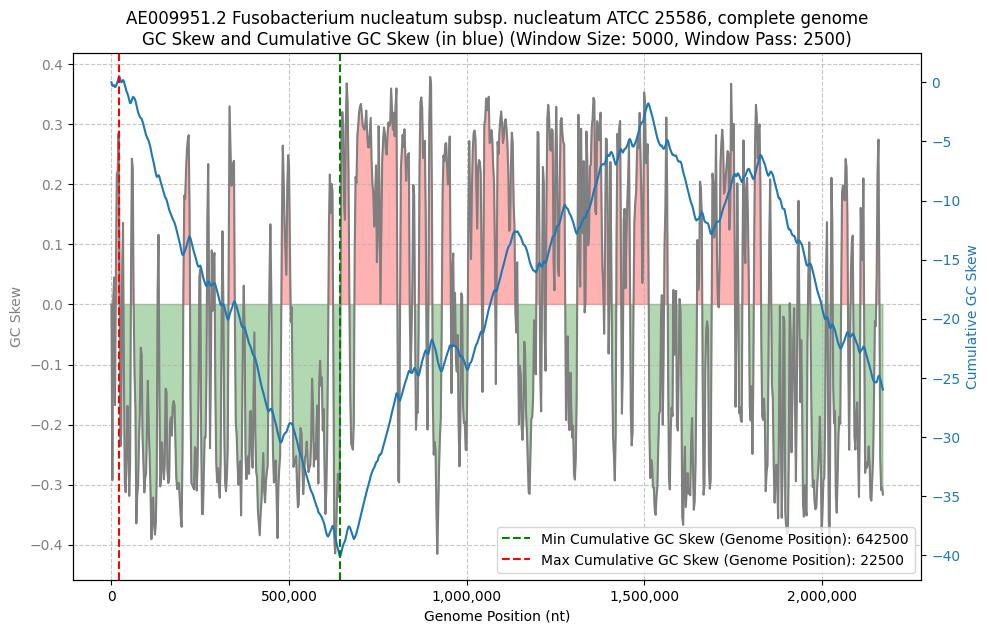

In [ ]:
def main():
    # Define window size and window pass
    window_size = 5000
    window_pass = window_size // 2

    # Read a fasta file or download it using Biopython

    # Read the FASTA file
    fasta_file_path = '25586.fasta'  # Update with your file path
    fasta_file_path = '25586.fasta'
    header, sequence = read_fasta(fasta_file_path)
    if header.count('|') > 3:
        name=header.split('|')[4]+' ('+header.split('|')[3]+')'
    else:
        name = header[1:]

    # Download from Biopython
    # Entrez.email = "A.N.Other@example.com"
    # with Entrez.efetch(
    #     db="nucleotide", rettype="fasta", retmode="text", id="AE009951.2" # Fusobacterium nucleatum subsp. nucleatum ATCC 25586
    # ) as handle:
    #     record = SeqIO.read(handle, "fasta")
    # sequence = str(record.seq)
    # header = str(record.description)
    # if header.count(',') > 0:
    #     name=" ".join(header.split(',')[0].split(' ')[1:]) + ' (' + header.split(',')[0].split(' ')[0] + ')' 


    # Calculate GC skew and cumulative GC skew with sliding window
    genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew = calculate_gc_skew(sequence, window_size, window_pass)
    print(f"Genome Positions: {genome_positions}")
    print(f"GC Skew Values: {gc_skew_values}")
    print(f"Cumulative GC Skew Values: {cumulative_gc_skew_values}")
    print(f'Min Cumulative GC Skew: {min(cumulative_gc_skew_values)} at Genome Position: {pos_min_cumulative_gc_skew}')
    print(f'Max Cumulative GC Skew: {max(cumulative_gc_skew_values)} at Genome Position: {pos_max_cumulative_gc_skew}')
    g = sequence.upper().count('G')
    c = sequence.upper().count('C')
    a = sequence.upper().count('A')
    t = sequence.upper().count('T')
    gc_percent = (g + c) / (g + c + a + t) * 100
    print(f"GC content: {gc_percent:.2f}%")

    # Plot the results
    plot_gc_skew2(name, genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew, window_size, window_pass)



if __name__ == "__main__":
    main()

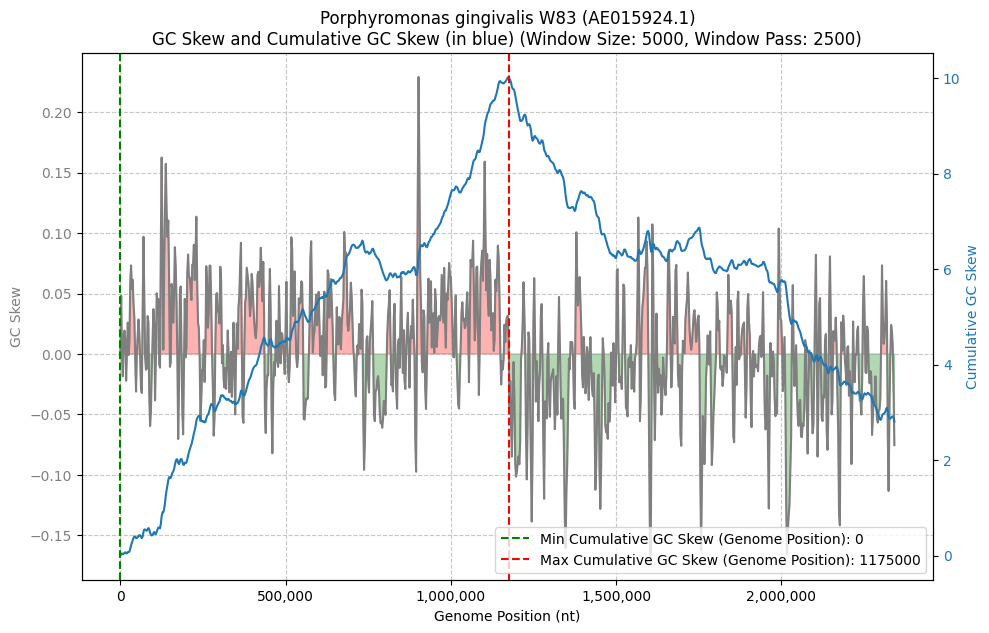

In [9]:
def main():
    # Define window size and window pass
    window_size = 5000
    window_pass = window_size // 2

    # Read a fasta file or download it using Biopython

    # Read the FASTA file
    # fasta_file_path = 'W83.fasta'  # Update with your file path
    # fasta_file_path = 'W83.fasta'
    # header, sequence = read_fasta(fasta_file_path)
    # if header.count('|') > 3:
    #     name=header.split('|')[4]+' ('+header.split('|')[3]+')'
    # else:
    #     name = header[1:]

    # Download from Biopython
    Entrez.email = "A.N.Other@example.com"
    with Entrez.efetch(
        db="nucleotide", rettype="fasta", retmode="text", id="AE015924.1" # Porphyromonas gingivalis W83
    ) as handle:
        record = SeqIO.read(handle, "fasta")
    sequence = str(record.seq)
    header = str(record.description)
    if header.count(',') > 0:
        name=" ".join(header.split(',')[0].split(' ')[1:]) + ' (' + header.split(',')[0].split(' ')[0] + ')' 


    # Calculate GC skew and cumulative GC skew with sliding window
    genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew = calculate_gc_skew(sequence, window_size, window_pass)

    # Plot the results
    plot_gc_skew2(name, genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew, window_size, window_pass)



if __name__ == "__main__":
    main()

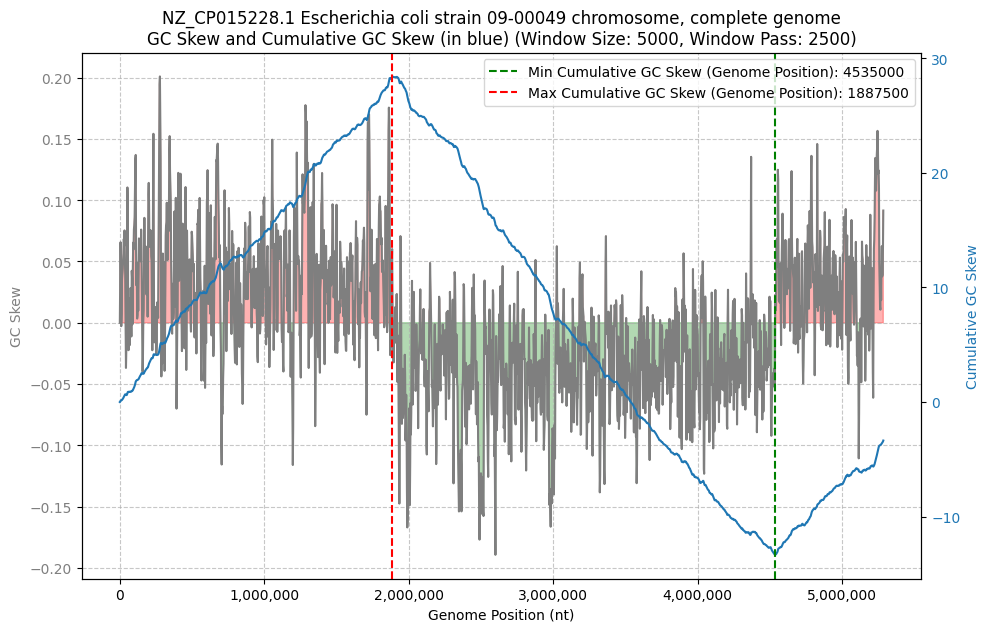

In [13]:
def main():
    # Define window size and window pass
    window_size = 5000
    window_pass = window_size // 2

    # Read a fasta file or download it using Biopython

    # Read the FASTA file
    fasta_file_path = 'E.coil.fasta'  # Update with your file path
    fasta_file_path = 'E.coil.fasta'
    header, sequence = read_fasta(fasta_file_path)
    if header.count('|') > 3:
        name=header.split('|')[4]+' ('+header.split('|')[3]+')'
    else:
        name = header[1:]


    # Calculate GC skew and cumulative GC skew with sliding window
    genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew = calculate_gc_skew(sequence, window_size, window_pass)

    # Plot the results
    plot_gc_skew2(name, genome_positions, gc_skew_values, cumulative_gc_skew_values, pos_min_cumulative_gc_skew, pos_max_cumulative_gc_skew, window_size, window_pass)



if __name__ == "__main__":
    main()

In [ ]:
# ============================================================================
# CAI calculation
# ============================================================================

import pandas as pd
import numpy as np
from Bio import SeqIO
from collections import Counter, defaultdict
import subprocess
import tempfile
import os

# Read the genome data
gb_file = '25586_NCBI.gb'
gb_record = SeqIO.read(gb_file, "genbank")

# Extract CDS features with complete information
cds_features = []
for feature in gb_record.features:
    if feature.type == 'CDS':
        qualifiers = feature.qualifiers
        locus_tag = qualifiers.get('locus_tag', [''])[0]
        protein_id = qualifiers.get('protein_id', [''])[0]
        product = qualifiers.get('product', [''])[0]
        translation = qualifiers.get('translation', [''])[0]
        
        # Get nucleotide sequence
        seq = feature.extract(gb_record.seq)
        
        cds_features.append({
            'locus_tag': locus_tag,
            'protein_id': protein_id,
            'product': product,
            'translation': translation,
            'nucleotide_seq': str(seq),
            'location': str(feature.location),
            'start': int(feature.location.start),
            'end': int(feature.location.end)
        })

print(f"Extracted {len(cds_features)} CDS features from genome")

# Create DataFrame
genome_df = pd.DataFrame(cds_features)

# Define codon table
codon_table = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

# Calculate whole genome codon usage
def calculate_codon_usage(sequences):
    """Calculate codon usage from a list of nucleotide sequences"""
    codon_counts = Counter()
    total_codons = 0
    
    for seq in sequences:
        # Ensure sequence length is multiple of 3
        seq_len = len(seq) - (len(seq) % 3)
        for i in range(0, seq_len, 3):
            codon = seq[i:i+3].upper()
            if codon in codon_table and codon_table[codon] != '*':  # Exclude stop codons
                codon_counts[codon] += 1
                total_codons += 1
    
    # Convert to frequencies
    codon_usage = {codon: count/total_codons for codon, count in codon_counts.items()}
    return codon_usage, codon_counts

# Calculate genome-wide codon usage
genome_sequences = [row['nucleotide_seq'] for _, row in genome_df.iterrows() if len(row['nucleotide_seq']) > 0]
genome_codon_usage, genome_codon_counts = calculate_codon_usage(genome_sequences)

print(f"Calculated codon usage for {len(genome_codon_counts)} different codons")
print(f"Total codons analyzed: {sum(genome_codon_counts.values())}")
print(f"Sample codon usage: {dict(list(genome_codon_usage.items())[:5])}")

=== SETTING UP CAI CALCULATION METHODS ===
Extracted 2067 CDS features from genome
Calculated codon usage for 61 different codons
Total codons analyzed: 643841
Sample codon usage: {'ATG': 0.02310974293342611, 'AAA': 0.08535647776391997, 'TTT': 0.04269377066698144, 'ATA': 0.048946867316620096, 'CTA': 0.007810934687290806}


In [ ]:
# Now implement CAI calculation methods
def calculate_rscu(codon_usage_dict):
    aa_codons = defaultdict(list)
    for codon, aa in codon_table.items():
        if aa != '*':  # Exclude stop codons
            aa_codons[aa].append(codon)

    rscu = {}
    for aa, codons in aa_codons.items():
        # Get observed frequencies for codons coding for this amino acid
        aa_usage = {codon: codon_usage_dict.get(codon, 0) for codon in codons}
        total_aa_usage = sum(aa_usage.values())
        n_syn = len(codons)
        if total_aa_usage > 0:
            expected_freq = total_aa_usage / n_syn
            for codon in codons:
                # RSCU = (observed / expected) × n_syn
                rscu[codon] = (aa_usage[codon] / expected_freq) if expected_freq > 0 else 0
        else:
            for codon in codons:
                rscu[codon] = 0
    return rscu

# Method 1: CAI using highly expressed genes (we'll use ribosomal proteins as reference)
def get_ribosomal_proteins(genome_df):
    """Get ribosomal proteins as reference set for highly expressed genes"""
    ribosomal_keywords = ['ribosomal', 'ribosome', 'rRNA', 'rplA', 'rplB', 'rplC', 'rpsA', 'rpsB', 'rpsC']
    ribosomal_prots = []
    
    for _, row in genome_df.iterrows():
        product = row['product'].lower()
        locus_tag = row['locus_tag'].lower()
        if any(keyword in product or keyword in locus_tag for keyword in ribosomal_keywords):
            ribosomal_prots.append(row)
    
    return pd.DataFrame(ribosomal_prots)

# Get ribosomal proteins
ribosomal_df = get_ribosomal_proteins(genome_df)
print(f"Ribosomal proteins found: {len(ribosomal_df)}")
print("Sample ribosomal proteins:")
print(ribosomal_df[['locus_tag', 'product']].head())

Ribosomal proteins found: 61
Sample ribosomal proteins:
    locus_tag                                  product
62     FN1557                SSU ribosomal protein S7P
63     FN1558               SSU ribosomal protein S12P
102    FN1608  Ribosomal protein L11 methyltransferase
114    FN1620                SSU ribosomal protein S2P
117    FN1623          Ribosome Recycling Factor (RRF)


In [19]:
# Now implement the CAI calculation function
def calculate_cai_for_gene(gene_sequence, reference_rscu):
    """
    Calculate CAI for a single gene using reference RSCU values and the correct mathematical formula.

    CAI = (∏ᵢ wᵢ)^(1/L)
    where wᵢ = RSCU_i / max_RSCU_for_amino_acid
    """
    if len(gene_sequence) < 3:
        return 0

    seq_len = len(gene_sequence) - (len(gene_sequence) % 3)
    weights = []
    for i in range(0, seq_len, 3):
        codon = gene_sequence[i:i+3].upper()
        aa = codon_table.get(codon)
        if aa and aa != '*' and codon in reference_rscu:
            rscu_i = reference_rscu[codon]
            # Find max RSCU for this amino acid among its synonymous codons
            synonymous_codons = [c for c, a in codon_table.items() if a == aa and a != '*']
            max_rscu = max([reference_rscu.get(c, 0) for c in synonymous_codons])
            if max_rscu > 0:
                w_i = rscu_i / max_rscu
                # Avoid log(0) by replacing 0 or negative weights with a small positive value
                weights.append(w_i if w_i > 0 else 1e-6)
    L = len(weights)
    if L == 0:
        return 0
    cai = np.exp(np.sum(np.log(weights)) / L)
    return cai

# Method 1: Calculate CAI using ribosomal proteins as reference
#The CAI for a certain organism is based on the codon usage frequency in a reference set of highly expressed genes, 
#such as the ones encoding ribosomal proteins. 
#The CAI for a specific gene can be determined by comparing its codon usage frequency with this reference set.
#https://pmc.ncbi.nlm.nih.gov/articles/PMC4794256/
print("=== METHOD 1: CAI using ribosomal proteins ===")
ribosomal_sequences = ribosomal_df['nucleotide_seq'].tolist()
ribosomal_codon_usage, _ = calculate_codon_usage(ribosomal_sequences)
ribosomal_rscu = calculate_rscu(ribosomal_codon_usage)

# Calculate CAI for all genes using ribosomal reference
genome_df['cai_ribosomal'] = genome_df['nucleotide_seq'].apply(
    lambda seq: calculate_cai_for_gene(seq, ribosomal_rscu)
)

print(f"CAI (ribosomal) calculated for {len(genome_df)} genes")
print(f"CAI (ribosomal) statistics:")
print(f"Mean: {genome_df['cai_ribosomal'].mean():.3f}")
print(f"Std: {genome_df['cai_ribosomal'].std():.3f}")
print(f"Min: {genome_df['cai_ribosomal'].min():.3f}")
print(f"Max: {genome_df['cai_ribosomal'].max():.3f}")

=== METHOD 1: CAI using ribosomal proteins ===
CAI (ribosomal) calculated for 2067 genes
CAI (ribosomal) statistics:
Mean: 0.716
Std: 0.071
Min: 0.256
Max: 0.895


In [20]:
# Task 1: Identify top 20 proteins using each CAI method
print("=== TASK 1: TOP 20 PROTEINS BY CAI METHODS ===")

# Top 20 by ribosomal CAI
top20_ribosomal = genome_df.nlargest(20, 'cai_ribosomal')[['locus_tag', 'protein_id', 'product', 'cai_ribosomal']]
print("\n--- Top 20 by Ribosomal CAI ---")
print(top20_ribosomal.to_string(index=False))


# Now check PAI overlap
print("\n=== PAI REGION ANALYSIS ===")

# Define PAI regions
pai_regions = [
    (366847, 372320, "PAI1"),
    (1496613, 1523855, "PAI2"), 
    (1967193, 1999047, "PAI3")
]

def check_gene_in_pai(start_pos, end_pos, pai_regions):
    """Check if a gene overlaps with any PAI region"""
    pai_membership = []
    for pai_start, pai_end, pai_name in pai_regions:
        # Check if gene overlaps with PAI region
        if not (end_pos < pai_start or start_pos > pai_end):
            pai_membership.append(pai_name)
    return pai_membership if pai_membership else ['Non-PAI']

# Add PAI membership to genome dataframe
genome_df['pai_membership'] = genome_df.apply(
    lambda row: check_gene_in_pai(row['start'], row['end'], pai_regions), axis=1
)

# Function to analyze PAI distribution for top 20 genes
def analyze_pai_distribution(top20_df, method_name):
    print(f"\n--- {method_name} PAI Distribution ---")
    
    # Get PAI membership for top 20
    top20_with_pai = top20_df.merge(genome_df[['locus_tag', 'pai_membership', 'start', 'end']], 
                                   on='locus_tag', how='left')
    
    # Count PAI membership
    pai_counts = {'PAI1': 0, 'PAI2': 0, 'PAI3': 0, 'Non-PAI': 0}
    
    for _, row in top20_with_pai.iterrows():
        membership = row['pai_membership']
        if isinstance(membership, list):
            for pai in membership:
                pai_counts[pai] += 1
        else:
            pai_counts['Non-PAI'] += 1
    
    total = sum(pai_counts.values())
    percentages = {pai: (count/total)*100 for pai, count in pai_counts.items()}
    
    print(f"PAI distribution (counts): {pai_counts}")
    print(f"PAI distribution (percentages): {percentages}")
    
    return pai_counts, percentages, top20_with_pai

# Analyze PAI distribution for each method
pai_dist_rib = analyze_pai_distribution(top20_ribosomal, "Ribosomal CAI")

=== TASK 1: TOP 20 PROTEINS BY CAI METHODS ===

--- Top 20 by Ribosomal CAI ---
locus_tag protein_id                                                  product  cai_ribosomal
   FN1634 AAL93749.1                               LSU ribosomal protein L24P       0.894541
   FN1641 AAL93756.1                               SSU ribosomal protein S19P       0.893168
   FN0702 AAL94898.1                       N-acyl-L-amino acid amidohydrolase       0.892833
   FN1973 AAL94063.1                         Translation initiation inhibitor       0.891679
   FN1656 AAL93771.1                               SSU ribosomal protein S18P       0.887316
   FN1633 AAL93748.1                               LSU ribosomal protein L24P       0.884810
   FN0472 AAL94668.1                                               Flavodoxin       0.880656
   FN0325 AAL94529.1                               LSU ribosomal protein L20P       0.876142
   FN2037 AAL94122.1                      LSU ribosomal protein L12P (L7/L12)      

=== CREATING VISUALIZATIONS FOR TASK 1 ===


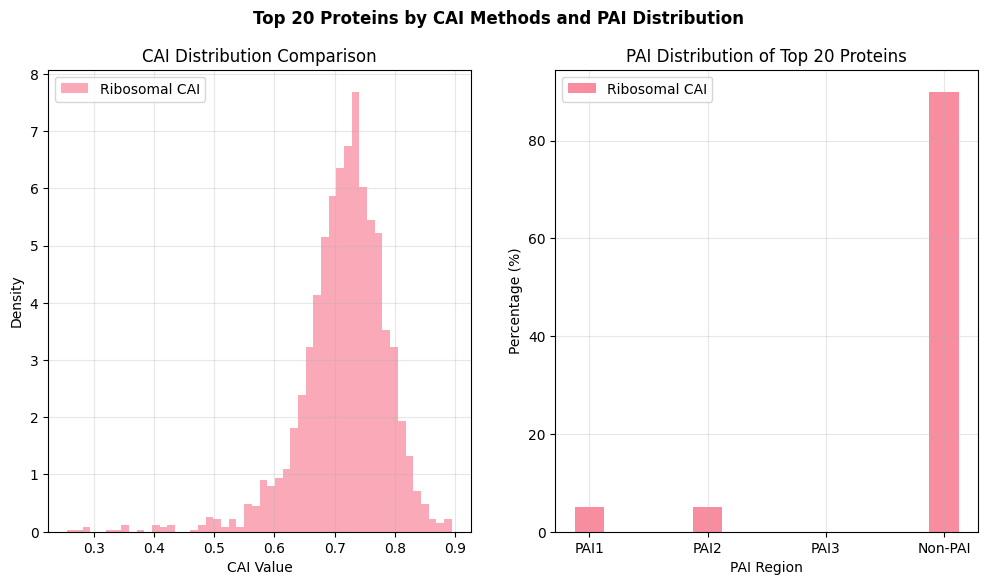

In [23]:
# Create visualizations for Task 1
import matplotlib.pyplot as plt
import seaborn as sns

print("=== CREATING VISUALIZATIONS FOR TASK 1 ===")

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Top 20 Proteins by CAI Methods and PAI Distribution', fontsize=12, fontweight='bold')

# Plot 1: CAI distributions comparison
methods_data = {
    'Ribosomal CAI': genome_df['cai_ribosomal']
}

ax1 = axes[0]
for method, data in methods_data.items():
    ax1.hist(data, alpha=0.6, bins=50, label=method, density=True)
ax1.set_xlabel('CAI Value')
ax1.set_ylabel('Density')
ax1.set_title('CAI Distribution Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 3: PAI distribution for each method
ax2 = axes[1]
pai_data = {
    'Ribosomal CAI': pai_dist_rib[1],
}

pai_names = ['PAI1', 'PAI2', 'PAI3', 'Non-PAI']
x = np.arange(len(pai_names))
width = 0.25

for i, (method, percentages) in enumerate(pai_data.items()):
    values = [percentages[pai] for pai in pai_names]
    ax2.bar(x + i*width, values, width, label=method, alpha=0.8)

ax2.set_xlabel('PAI Region')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('PAI Distribution of Top 20 Proteins')
ax2.set_xticks(x)
ax2.set_xticklabels(pai_names)
ax2.legend()
ax2.grid(True, alpha=0.3)

In [24]:
# Task 2: Calculate CAI for all proteins in the 3 PAI regions
print("=== TASK 2: PAI REGIONS CAI ANALYSIS ===")

# Define PAI regions more precisely
pai_regions_detailed = [
    {'name': 'PAI1', 'start': 366847, 'end': 372320, 'file': '366,847_372,320_list.xlsx'},
    {'name': 'PAI2', 'start': 1496613, 'end': 1523855, 'file': '1496613_1523855_list.xlsx'},
    {'name': 'PAI3', 'start': 1967193, 'end': 1999047, 'file': '1967193_1999047_list.xlsx'}
]

pai_analysis_results = {}

for pai in pai_regions_detailed:
    print(f"\n--- Analyzing {pai['name']} ({pai['start']}-{pai['end']}) ---")
    
    # Get genes in this PAI region from genome
    pai_genes = genome_df[
        (genome_df['start'] >= pai['start']) & 
        (genome_df['end'] <= pai['end'])
    ].copy()
    
    print(f"Genes found in {pai['name']}: {len(pai_genes)}")
    
    if len(pai_genes) > 0:
        # Calculate CAI statistics for this PAI
        pai_cai_stats = {
            'ribosomal': {
                'mean': pai_genes['cai_ribosomal'].mean(),
                'std': pai_genes['cai_ribosomal'].std(),
                'median': pai_genes['cai_ribosomal'].median(),
                'min': pai_genes['cai_ribosomal'].min(),
                'max': pai_genes['cai_ribosomal'].max()
            }
        }
        
        print(f"CAI Statistics for {pai['name']}:")
        print(f"  Ribosomal CAI: Mean={pai_cai_stats['ribosomal']['mean']:.3f}, Std={pai_cai_stats['ribosomal']['std']:.3f}")
        
        # Read the PAI-specific file to get more details
        try:
            pai_file_df = pd.read_excel(pai['file'])
            print(f"  PAI file contains {len(pai_file_df)} entries")
            if 'Decision' in pai_file_df.columns:
                print(f"  Columns in PAI file: {pai_file_df.columns.tolist()}")
        except Exception as e:
            print(f"  Error reading PAI file: {e}")
            pai_file_df = None
        
        # Store results
        pai_analysis_results[pai['name']] = {
            'genes': pai_genes,
            'stats': pai_cai_stats,
            'file_data': pai_file_df
        }
        
        # Show top 5 genes by CAI in this PAI
        top_pai_genes = pai_genes.nlargest(5, 'cai_ribosomal')[['locus_tag', 'product', 'cai_ribosomal']]
        print(f"  Top 5 genes by ribosomal CAI in {pai['name']}:")
        print(top_pai_genes.to_string(index=False))
    else:
        print(f"  No genes found in {pai['name']} region")

# Compare CAI between PAI regions and genome-wide
print(f"\n=== PAI vs GENOME-WIDE CAI COMPARISON ===")

genome_wide_cai = {
    'ribosomal': {
        'mean': genome_df['cai_ribosomal'].mean(),
        'std': genome_df['cai_ribosomal'].std()
    }
}

print(f"Genome-wide CAI:")
print(f"  Ribosomal CAI: Mean={genome_wide_cai['ribosomal']['mean']:.3f}, Std={genome_wide_cai['ribosomal']['std']:.3f}")

# Statistical comparison
from scipy import stats

for pai_name, pai_data in pai_analysis_results.items():
    if len(pai_data['genes']) > 1:  # Need at least 2 genes for t-test
        pai_cai = pai_data['genes']['cai_ribosomal'].values
        genome_cai = genome_df['cai_ribosomal'].values
        
        t_stat, p_value = stats.ttest_ind(pai_cai, genome_cai)
        print(f"\n{pai_name} vs Genome-wide (ribosomal CAI):")
        print(f"  t-statistic: {t_stat:.3f}")
        print(f"  p-value: {p_value:.3f}")
        print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

=== TASK 2: PAI REGIONS CAI ANALYSIS ===

--- Analyzing PAI1 (366847-372320) ---
Genes found in PAI1: 9
CAI Statistics for PAI1:
  Ribosomal CAI: Mean=0.706, Std=0.115
  PAI file contains 10 entries
  Columns in PAI file: ['locus_tag', 'protein_id', 'product', 'Blast_Result', 'hit_id', 'id mapping', 'Decision']
  Top 5 genes by ribosomal CAI in PAI1:
locus_tag                                   product  cai_ribosomal
   FN1884                                   unknown       0.862872
   FN1879                SSU ribosomal protein S20P       0.827737
   FN1881                                  Esterase       0.795734
   FN1885                             Hemolysin III       0.722699
   FN1880 Oxygen-insensitive NAD(P)H nitroreductase       0.702174

--- Analyzing PAI2 (1496613-1523855) ---
Genes found in PAI2: 31
CAI Statistics for PAI2:
  Ribosomal CAI: Mean=0.699, Std=0.082
  PAI file contains 32 entries
  Columns in PAI file: ['locus_tag', 'protein_id', 'product', 'Blast_Result', 'hit_i

=== CREATING COMPREHENSIVE VISUALIZATIONS ===
Comprehensive visualization saved at: comprehensive_cai_analysis.png


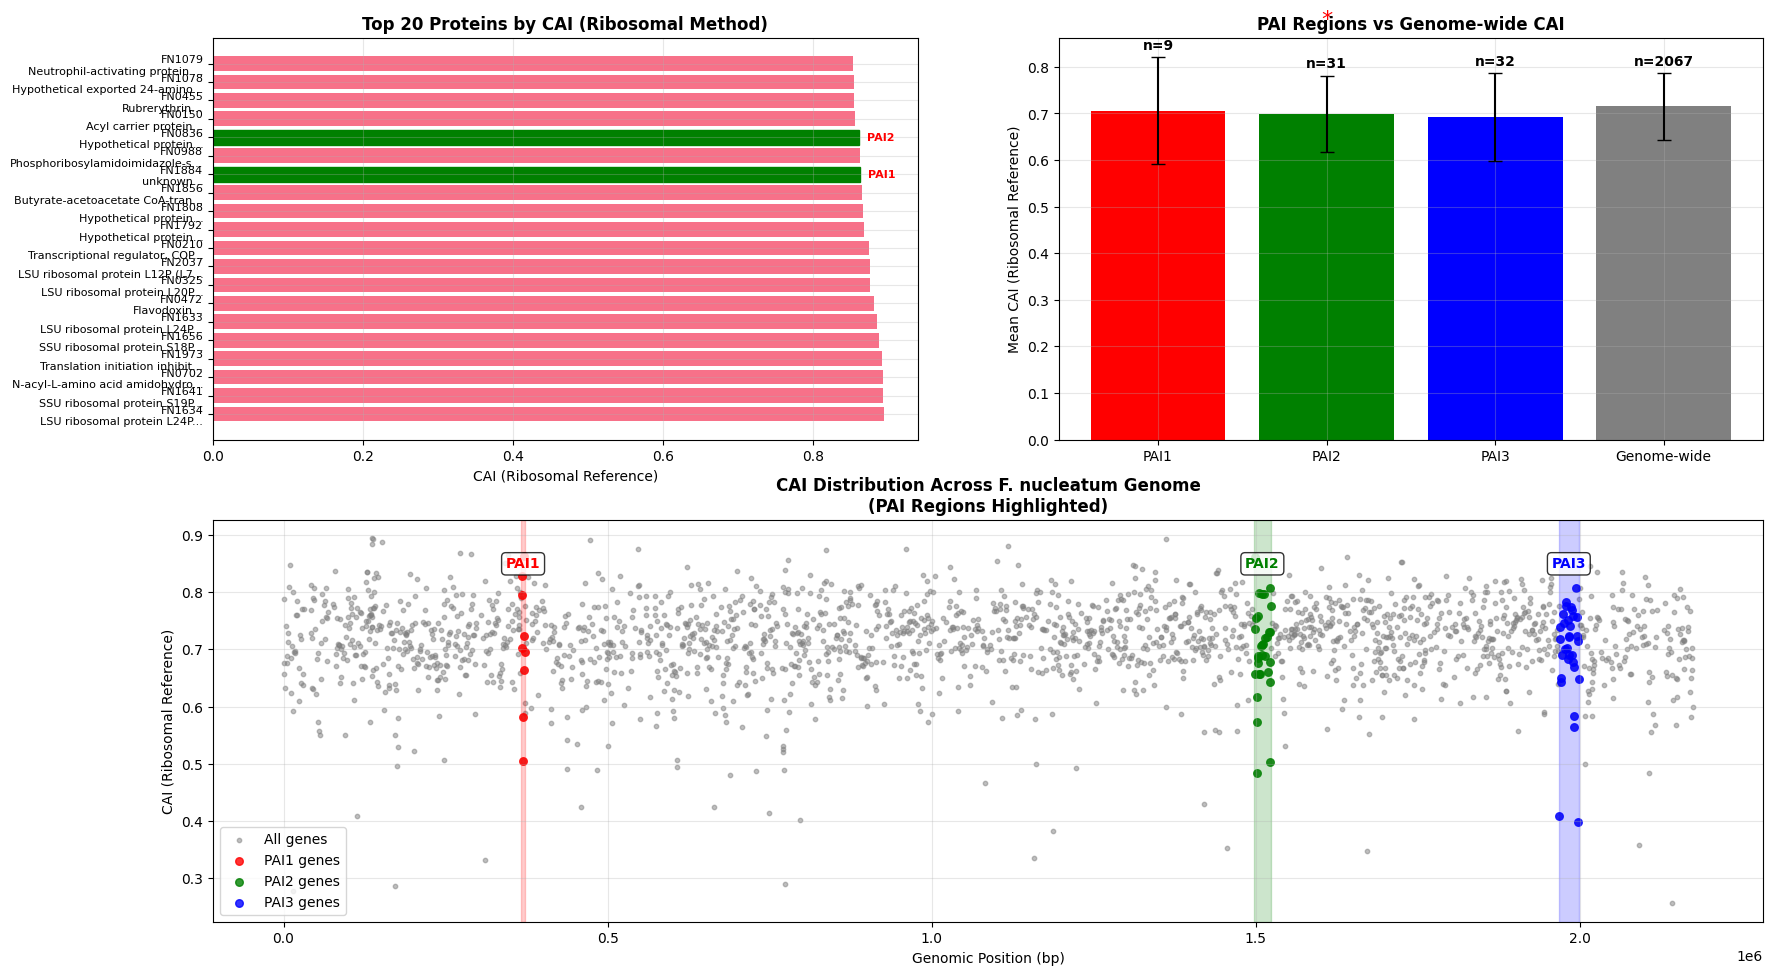

In [25]:
# Create comprehensive visualizations for all analyses
print("=== CREATING COMPREHENSIVE VISUALIZATIONS ===")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(20, 24))

# 1. Top 20 proteins by different CAI methods (Task 1)
ax1 = plt.subplot(4, 2, 1)
top20_ribosomal = genome_df.nlargest(20, 'cai_ribosomal')
bars1 = ax1.barh(range(len(top20_ribosomal)), top20_ribosomal['cai_ribosomal'].values)
ax1.set_yticks(range(len(top20_ribosomal)))
ax1.set_yticklabels([f"{tag}\n{prod[:30]}..." for tag, prod in zip(top20_ribosomal['locus_tag'], top20_ribosomal['product'])], fontsize=8)
ax1.set_xlabel('CAI (Ribosomal Reference)')
ax1.set_title('Top 20 Proteins by CAI (Ribosomal Method)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add PAI information to bars
for i, (idx, row) in enumerate(top20_ribosomal.iterrows()):
    is_in_pai = False
    pai_name = ""
    for pai_name_check, pai_data in pai_analysis_results.items():
        if row['locus_tag'] in pai_data['genes']['locus_tag'].values:
            is_in_pai = True
            pai_name = pai_name_check
            break
    
    if is_in_pai:
        bars1[i].set_color('green')
        ax1.text(row['cai_ribosomal'] + 0.01, i, pai_name, va='center', fontsize=8, color='red', fontweight='bold')


# 2. PAI regions CAI comparison (Task 3)
ax2 = plt.subplot(4, 2, 2)
pai_names = list(pai_analysis_results.keys())
pai_means = [pai_analysis_results[name]['stats']['ribosomal']['mean'] for name in pai_names]
pai_stds = [pai_analysis_results[name]['stats']['ribosomal']['std'] for name in pai_names]
pai_counts = [len(pai_analysis_results[name]['genes']) for name in pai_names]

# Add genome-wide for comparison
pai_names.append('Genome-wide')
pai_means.append(genome_wide_cai['ribosomal']['mean'])
pai_stds.append(genome_wide_cai['ribosomal']['std'])
pai_counts.append(len(genome_df))

colors = ['red', 'green', 'blue', 'gray']
bars2 = ax2.bar(pai_names, pai_means, yerr=pai_stds, capsize=5, color=colors)
ax2.set_ylabel('Mean CAI (Ribosomal Reference)')
ax2.set_title('PAI Regions vs Genome-wide CAI', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add count annotations
for i, (bar, count) in enumerate(zip(bars2, pai_counts)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + pai_stds[i] + 0.01,
             f'n={count}', ha='center', va='bottom', fontweight='bold')

# Add significance markers
significance_markers = ['ns', '*', 'ns', '-']  # Based on p-values from previous analysis
for i, (bar, marker) in enumerate(zip(bars2[:-1], significance_markers[:-1])):
    if marker == '*':
        ax2.text(bar.get_x() + bar.get_width()/2.,
                max(pai_means) + max(pai_stds) + 0.05,
                marker, ha='center', va='bottom', fontsize=16, color='red')

# 3. CAI distribution across genome
ax5 = plt.subplot(4, 2, (3, 4))

# Create a genomic position plot
genome_df_sorted = genome_df.sort_values('start')
positions = genome_df_sorted['start'].values
cai_values = genome_df_sorted['cai_ribosomal'].values

# Plot all genes
ax5.scatter(positions, cai_values, alpha=0.5, s=10, color='gray', label='All genes')

# Highlight PAI regions
colors_pai = ['red', 'green', 'blue']
for i, (pai_name, pai_data) in enumerate(pai_analysis_results.items()):
    pai_genes = pai_data['genes'].sort_values('start')
    ax5.scatter(pai_genes['start'], pai_genes['cai_ribosomal'], 
               s=30, color=colors_pai[i], label=f'{pai_name} genes', alpha=0.8)
    
    # Add PAI region rectangles
    pai_regions_dict = {
        'PAI1': (366847, 372320),
        'PAI2': (1496613, 1523855), 
        'PAI3': (1967193, 1999047)
    }
    start, end = pai_regions_dict[pai_name]
    ax5.axvspan(start, end, alpha=0.2, color=colors_pai[i])
    
    # Add PAI labels
    ax5.text((start + end) / 2, max(cai_values) * 0.95, pai_name, 
             ha='center', va='center', fontweight='bold', color=colors_pai[i],
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax5.set_xlabel('Genomic Position (bp)')
ax5.set_ylabel('CAI (Ribosomal Reference)')
ax5.set_title('CAI Distribution Across F. nucleatum Genome\n(PAI Regions Highlighted)', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)


# Save the figure
output_path = 'comprehensive_cai_analysis.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Comprehensive visualization saved at: {output_path}")

plt.show()

In [ ]:
# ============================================================================
# Promotor analysis
# ============================================================================

#try merge gne bank and promoter
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation
import pandas as pd

# === File paths ===
gbk_file = "25586_NCBI.gb"  # Your downloaded GenBank
promoter_file = "promoters_coordinates.xlsx"  # Your promoter coordinates, it is the Start	End	Strand	Label	Score from the PEPper anlaysis

# === Load data ===
record = SeqIO.read(gbk_file, "genbank")
promoters_df = pd.read_excel(promoter_file)

# If 'End' column missing, create it (assuming 30 bp length)
if 'End' not in promoters_df.columns:
    promoters_df['End'] = promoters_df['Start'] + 30

# === Add promoters to GenBank ===
for idx, row in promoters_df.iterrows():
    start = int(row['Start']) - 1  # GenBank uses 0-based start
    end = int(row['End'])
    strand = 1 if row['Strand'] == '+' else -1
    label = f"promoter_{idx+1}"
    qualifiers = {
        "label": label,
        "note": f"Predicted promoter; score={row.get('Score', 'NA')}"
    }
    feature = SeqFeature(FeatureLocation(start, end, strand=strand),
                         type="promoter", qualifiers=qualifiers)
    record.features.append(feature)

# === Save updated GenBank ===
output_gbk = "genome_with_promoters.gbk"
SeqIO.write(record, output_gbk, "genbank")
print(f"Saved updated GenBank with promoters to {output_gbk}")

#

In [ ]:
from Bio import SeqIO
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load genome =====
gbk_file = "genome_with_promoters.gbk"
record = SeqIO.read(gbk_file, "genbank")

# ===== Extract features =====
def get_features_in_region(record, start, end):
    genes, promoters = [], []
    for feat in record.features:
        if feat.type.lower() in ["cds", "gene"]:
            loc_start = int(feat.location.start)
            loc_end = int(feat.location.end)
            if loc_end >= start and loc_start <= end:
                genes.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("locus_tag", ["NA"])[0]
                })
        elif feat.type.lower() == "promoter":
            loc_start = int(feat.location.start)
            loc_end = int(feat.location.end)
            if loc_end >= start and loc_start <= end:
                promoters.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("label", ["promoter"])[0]
                })
    return pd.DataFrame(genes), pd.DataFrame(promoters)

# ===== Plotting =====
def plot_region(record, start, end, title=None, outfile="region_plot.png"):
    genes, promoters = get_features_in_region(record, start, end)
    fig, ax = plt.subplots(figsize=(15, 3))

    # Forward strand genes
    for _, row in genes[genes["strand"] == 1].iterrows():
        ax.arrow(row["start"], 1, row["end"] - row["start"], 0, 
                 head_width=0.2, head_length=100, fc="blue", ec="blue", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, 1.1, row["label"], ha="center", fontsize=8)

    # Reverse strand genes
    for _, row in genes[genes["strand"] == -1].iterrows():
        ax.arrow(row["end"], -1, row["start"] - row["end"], 0, 
                 head_width=0.2, head_length=100, fc="red", ec="red", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, -1.3, row["label"], ha="center", fontsize=8)

    # Promoters
    for _, row in promoters.iterrows():
        color = "green" if row["strand"] == 1 else "orange"
        y = 0.3 if row["strand"] == 1 else -0.3
        ax.plot([row["start"], row["end"]], [y, y], color=color, linewidth=5)
        ax.text((row["start"] + row["end"]) / 2, y + 0.2, row["label"], ha="center", fontsize=7)

    # Styling
    ax.set_xlim(start, end)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("Genome Position (bp)")
    ax.set_yticks([1, 0.3, -0.3, -1])
    ax.set_yticklabels(["Forward (+)", "Promoters (+)", "Promoters (-)", "Reverse (-)"])
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Region: {start}-{end}")
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.close()
    print(f"Saved plot to {outfile}")

# Example: plot region
plot_region(record, 1967193, 1999047, title="PAI3 Region", outfile="PAI3.png")


In [ ]:
from Bio import SeqIO
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load genome =====
gbk_file = "genome_with_promoters.gbk"
record = SeqIO.read(gbk_file, "genbank")

# ===== Extract features =====
def get_features_in_region(record, start, end):
    genes, promoters = [], []
    for feat in record.features:
        if feat.type.lower() in ["cds", "gene"]:
            loc_start = int(feat.location.start)
            loc_end = int(feat.location.end)
            if loc_end >= start and loc_start <= end:
                genes.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("locus_tag", ["NA"])[0]
                })
        elif feat.type.lower() == "promoter":
            loc_start = int(feat.location.start)
            loc_end = int(feat.location.end)
            if loc_end >= start and loc_start <= end:
                promoters.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("label", ["promoter"])[0]
                })
    return pd.DataFrame(genes), pd.DataFrame(promoters)

# ===== Plotting =====
def plot_region(record, start, end, title=None, outfile="region_plot.png"):
    genes, promoters = get_features_in_region(record, start, end)
    fig, ax = plt.subplots(figsize=(15, 3))

    # Forward strand genes
    for _, row in genes[genes["strand"] == 1].iterrows():
        ax.arrow(row["start"], 1, row["end"] - row["start"], 0, 
                 head_width=0.2, head_length=100, fc="blue", ec="blue", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, 1.1, row["label"], ha="center", fontsize=8)

    # Reverse strand genes
    for _, row in genes[genes["strand"] == -1].iterrows():
        ax.arrow(row["end"], -1, row["start"] - row["end"], 0, 
                 head_width=0.2, head_length=100, fc="red", ec="red", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, -1.3, row["label"], ha="center", fontsize=8)

    # Promoters
    for _, row in promoters.iterrows():
        color = "green" if row["strand"] == 1 else "orange"
        y = 0.3 if row["strand"] == 1 else -0.3
        ax.plot([row["start"], row["end"]], [y, y], color=color, linewidth=5)
        ax.text((row["start"] + row["end"]) / 2, y + 0.2, row["label"], ha="center", fontsize=7)

    # Styling
    ax.set_xlim(start, end)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("Genome Position (bp)")
    ax.set_yticks([1, 0.3, -0.3, -1])
    ax.set_yticklabels(["Forward (+)", "Promoters (+)", "Promoters (-)", "Reverse (-)"])
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Region: {start}-{end}")
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.close()
    print(f"Saved plot to {outfile}")

# Example: plot region
plot_region(record, 368823, 373471, title="FN1885 relate Region", outfile="region_FN1885.png")


In [ ]:
from Bio import SeqIO
import pandas as pd

gbk_file = "genome_with_promoters.gbk"
record = SeqIO.read(gbk_file, "genbank")

def find_operon_by_locus_tag(record, locus_tag, flank_bp=2000):
    # Find the gene feature by locus_tag
    for feat in record.features:
        if feat.type.lower() in ["cds", "gene"]:
            if locus_tag in feat.qualifiers.get("locus_tag", []):
                start = int(feat.location.start)
                end = int(feat.location.end)
                # Search surrounding region for other genes in the operon
                operon_genes = []
                promoters = []
                region_start = max(0, start - flank_bp)
                region_end = min(len(record.seq), end + flank_bp)
                for f in record.features:
                    if f.type.lower() in ["cds", "gene"]:
                        s, e = int(f.location.start), int(f.location.end)
                        if e >= region_start and s <= region_end:
                            operon_genes.append(f.qualifiers.get("locus_tag", ["NA"])[0])
                    elif f.type.lower() == "promoter":
                        s, e = int(f.location.start), int(f.location.end)
                        if e >= region_start and s <= region_end:
                            promoters.append(f.qualifiers.get("label", ["promoter"])[0])
                return {
                    "locus_tag": locus_tag,
                    "operon_genes": operon_genes,
                    "promoters": promoters,
                    "region_start": region_start,
                    "region_end": region_end
                }
    return None

# Example usage
result = find_operon_by_locus_tag(record, "FN1885")
if result:
    print("Locus tag:", result["locus_tag"])
    print("Operon genes:", result["operon_genes"])
    print("Promoters:", result["promoters"])
    print("Region:", result["region_start"], "-", result["region_end"])
else:
    print("No match found")


In [ ]:
from Bio import SeqIO
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load genome =====
gbk_file = "genome_with_promoters.gbk"
record = SeqIO.read(gbk_file, "genbank")

# ===== Extract features =====
def get_features_in_region(record, start, end):
    orfs, genes, promoters = [], [], []
    for feat in record.features:
        loc_start = int(feat.location.start)
        loc_end = int(feat.location.end)

        if loc_end >= start and loc_start <= end:
            if feat.type.lower() == "cds":  # ORF
                orfs.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("locus_tag", ["NA"])[0]
                })
            elif feat.type.lower() == "gene":  # Annotated gene
                genes.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "locus_tag": feat.qualifiers.get("locus_tag", ["NA"])[0]
                })
            elif feat.type.lower() == "promoter":
                promoters.append({
                    "start": loc_start,
                    "end": loc_end,
                    "strand": feat.location.strand,
                    "label": feat.qualifiers.get("label", ["promoter"])[0]
                })
    return pd.DataFrame(orfs), pd.DataFrame(genes), pd.DataFrame(promoters)

# ===== Plotting =====
def plot_region(record, start, end, title=None, outfile="region_plot.png"):
    orfs, genes, promoters = get_features_in_region(record, start, end)
    fig, ax = plt.subplots(figsize=(15, 3))

    # ORFs (blue = forward, red = reverse)
    for _, row in orfs[orfs["strand"] == 1].iterrows():
        ax.arrow(row["start"], 1.5, row["end"] - row["start"], 0,
                 head_width=0.2, head_length=100, fc="blue", ec="blue", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, 1.6, row["label"], ha="center", fontsize=7)

    for _, row in orfs[orfs["strand"] == -1].iterrows():
        ax.arrow(row["end"], -1.5, row["start"] - row["end"], 0,
                 head_width=0.2, head_length=100, fc="red", ec="red", length_includes_head=True)
        ax.text((row["start"] + row["end"]) / 2, -1.6, row["label"], ha="center", fontsize=7)

    # Promoters (green = forward, orange = reverse)
    for _, row in promoters.iterrows():
        color = "green" if row["strand"] == 1 else "orange"
        y = 0.3 if row["strand"] == 1 else -0.3
        ax.plot([row["start"], row["end"]], [y, y], color=color, linewidth=5)
        ax.text((row["start"] + row["end"]) / 2, y + 0.2, row["label"], ha="center", fontsize=7)

    # Stats
    orf_count = len(orfs)
    gene_count = len(genes)
    promoter_count = len(promoters)
    ratio = promoter_count / orf_count if orf_count > 0 else 0

    # Styling
    ax.set_xlim(start, end)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("Genome Position (bp)")
    ax.set_yticks([1.5, 0.3, -0.3, -1.5])
    ax.set_yticklabels(["ORF (+)", "Promoters (+)", "Promoters (-)", "ORF (-)"])
    if title:
        ax.set_title(f"{title} | ORFs: {orf_count}, Genes: {gene_count}, Promoters: {promoter_count}, Ratio: {ratio:.2f}")
    else:
        ax.set_title(f"Region: {start}-{end} | ORFs: {orf_count}, Genes: {gene_count}, Promoters: {promoter_count}, Ratio: {ratio:.2f}")

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.close()
    print(f"Saved plot to {outfile}")

    # ===== Print promoters and gene locus tags =====
    print("\nPromoters in region:")
    if not promoters.empty:
        for p in promoters["label"]:
            print(f" - {p}")
    else:
        print(" None found")

    print("\nGenes (locus_tag) in region:")
    if not genes.empty:
        for g in genes["locus_tag"]:
            print(f" - {g}")
    else:
        print(" None found")

# ===== Example usage =====
plot_region(record, 0, 2174501, title="whole Region", outfile="wholeG.png")


In [ ]:
# Implement the CAI calculation from the notebook
print("=== IMPLEMENTING CAI CALCULATION ===")

from Bio import SeqIO
from collections import Counter, defaultdict
import pandas as pd
import numpy as np

# Read the genome data
gb_file = 'genome_with_promoters.gbk'
gb_record = SeqIO.read(gb_file, "genbank")

print(f"Genome length: {len(gb_record.seq)}")
print(f"Total features: {len(gb_record.features)}")

# Extract CDS features with complete information
cds_features = []
promoter_features = []

for feature in gb_record.features:
    if feature.type == 'CDS':
        qualifiers = feature.qualifiers
        locus_tag = qualifiers.get('locus_tag', [''])[0]
        protein_id = qualifiers.get('protein_id', [''])[0] 
        product = qualifiers.get('product', [''])[0]
        translation = qualifiers.get('translation', [''])[0]
        
        # Get nucleotide sequence
        seq = feature.extract(gb_record.seq)
        
        cds_features.append({
            'locus_tag': locus_tag,
            'protein_id': protein_id,
            'product': product,
            'translation': translation,
            'nucleotide_seq': str(seq),
            'location': str(feature.location),
            'start': int(feature.location.start),
            'end': int(feature.location.end),
            'strand': feature.location.strand
        })
    
    elif feature.type == 'promoter':
        qualifiers = feature.qualifiers
        promoter_features.append({
            'locus_tag': qualifiers.get('locus_tag', [''])[0],
            'note': qualifiers.get('note', [''])[0],
            'location': str(feature.location),
            'start': int(feature.location.start),
            'end': int(feature.location.end),
            'strand': feature.location.strand,
            'sequence': str(feature.extract(gb_record.seq))
        })

print(f"Extracted {len(cds_features)} CDS features")
print(f"Extracted {len(promoter_features)} promoter features")

# Create DataFrames
genome_df = pd.DataFrame(cds_features)
promoter_df = pd.DataFrame(promoter_features)

print("\nFirst few CDS features:")
print(genome_df[['locus_tag', 'product', 'start', 'end']].head())
print("\nFirst few promoter features:")
print(promoter_df[['locus_tag', 'start', 'end', 'strand']].head())

In [ ]:
# Define codon table and implement CAI calculation functions
print("=== SETTING UP CAI CALCULATION FUNCTIONS ===")

# Define codon table
codon_table = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

def calculate_codon_usage(sequences):
    """Calculate codon usage from a list of nucleotide sequences"""
    codon_counts = Counter()
    total_codons = 0
    
    for seq in sequences:
        # Ensure sequence length is multiple of 3
        seq_len = len(seq) - (len(seq) % 3)
        for i in range(0, seq_len, 3):
            codon = seq[i:i+3].upper()
            if codon in codon_table and codon_table[codon] != '*':  # Exclude stop codons
                codon_counts[codon] += 1
                total_codons += 1
    
    # Convert to frequencies
    codon_usage = {codon: count/total_codons for codon, count in codon_counts.items()}
    return codon_usage, codon_counts

def calculate_rscu(codon_usage_dict):
    """Calculate Relative Synonymous Codon Usage (RSCU) for each codon."""
    aa_codons = defaultdict(list)
    for codon, aa in codon_table.items():
        if aa != '*':  # Exclude stop codons
            aa_codons[aa].append(codon)

    rscu = {}
    for aa, codons in aa_codons.items():
        # Get observed frequencies for codons coding for this amino acid
        aa_usage = {codon: codon_usage_dict.get(codon, 0) for codon in codons}
        total_aa_usage = sum(aa_usage.values())
        n_syn = len(codons)
        if total_aa_usage > 0:
            expected_freq = total_aa_usage / n_syn
            for codon in codons:
                # RSCU = (observed / expected) × n_syn
                rscu[codon] = (aa_usage[codon] / expected_freq) if expected_freq > 0 else 0
        else:
            for codon in codons:
                rscu[codon] = 0
    return rscu

def calculate_cai_for_gene(gene_sequence, reference_rscu):
    """Calculate CAI for a single gene using reference RSCU values."""
    if len(gene_sequence) < 3:
        return 0

    seq_len = len(gene_sequence) - (len(gene_sequence) % 3)
    weights = []
    for i in range(0, seq_len, 3):
        codon = gene_sequence[i:i+3].upper()
        aa = codon_table.get(codon)
        if aa and aa != '*' and codon in reference_rscu:
            rscu_i = reference_rscu[codon]
            # Find max RSCU for this amino acid among its synonymous codons
            synonymous_codons = [c for c, a in codon_table.items() if a == aa and a != '*']
            max_rscu = max([reference_rscu.get(c, 0) for c in synonymous_codons])
            if max_rscu > 0:
                w_i = rscu_i / max_rscu
                # Avoid log(0) by replacing 0 or negative weights with a small positive value
                weights.append(w_i if w_i > 0 else 1e-6)
    L = len(weights)
    if L == 0:
        return 0
    cai = np.exp(np.sum(np.log(weights)) / L)
    return cai

print("CAI calculation functions set up successfully")

In [ ]:
# Calculate CAI using ribosomal proteins as reference
print("=== CALCULATING CAI VALUES ===")

def get_ribosomal_proteins(genome_df):
    """Get ribosomal proteins as reference set for highly expressed genes"""
    ribosomal_keywords = ['ribosomal', 'ribosome', 'rRNA', 'rplA', 'rplB', 'rplC', 'rpsA', 'rpsB', 'rpsC']
    ribosomal_prots = []
    
    for _, row in genome_df.iterrows():
        product = row['product'].lower()
        locus_tag = row['locus_tag'].lower()
        if any(keyword in product or keyword in locus_tag for keyword in ribosomal_keywords):
            ribosomal_prots.append(row)
    
    return pd.DataFrame(ribosomal_prots)

# Get ribosomal proteins
ribosomal_df = get_ribosomal_proteins(genome_df)
print(f"Ribosomal proteins found: {len(ribosomal_df)}")
print("Sample ribosomal proteins:")
print(ribosomal_df[['locus_tag', 'product']].head(10))

# Calculate genome-wide codon usage for ribosomal proteins
ribosomal_sequences = ribosomal_df['nucleotide_seq'].tolist()
ribosomal_codon_usage, _ = calculate_codon_usage(ribosomal_sequences)
ribosomal_rscu = calculate_rscu(ribosomal_codon_usage)

print(f"\nReference codon usage calculated from {len(ribosomal_sequences)} ribosomal sequences")

# Calculate CAI for all genes using ribosomal reference
genome_df['cai'] = genome_df['nucleotide_seq'].apply(
    lambda seq: calculate_cai_for_gene(seq, ribosomal_rscu)
)

print(f"\nCAI calculated for {len(genome_df)} genes")
print(f"CAI statistics:")
print(f"Mean: {genome_df['cai'].mean():.3f}")
print(f"Std: {genome_df['cai'].std():.3f}")
print(f"Min: {genome_df['cai'].min():.3f}")
print(f"Max: {genome_df['cai'].max():.3f}")

In [ ]:
# Identify high and low CAI genes and associate them with promoters
print("=== IDENTIFYING HIGH AND LOW CAI GENES ===")

# Define thresholds for high and low CAI
high_cai_threshold = genome_df['cai'].quantile(0.8)  # Top 20%
low_cai_threshold = genome_df['cai'].quantile(0.2)   # Bottom 20%

print(f"High CAI threshold (top 20%): {high_cai_threshold:.3f}")
print(f"Low CAI threshold (bottom 20%): {low_cai_threshold:.3f}")

# Filter high and low CAI genes
high_cai_genes = genome_df[genome_df['cai'] >= high_cai_threshold].copy()
low_cai_genes = genome_df[genome_df['cai'] <= low_cai_threshold].copy()

print(f"\nHigh CAI genes: {len(high_cai_genes)}")
print(f"Low CAI genes: {len(low_cai_genes)}")

# Show top and bottom genes
print(f"\nTop 10 highest CAI genes:")
top_cai = high_cai_genes.nlargest(10, 'cai')[['locus_tag', 'product', 'cai', 'start', 'end']]
print(top_cai.to_string(index=False))

print(f"\nTop 10 lowest CAI genes:")  
bottom_cai = low_cai_genes.nsmallest(10, 'cai')[['locus_tag', 'product', 'cai', 'start', 'end']]
print(bottom_cai.to_string(index=False))

In [ ]:
# Associate promoters with high and low CAI genes
print("=== ASSOCIATING PROMOTERS WITH CAI GENES ===")

def find_associated_promoter(gene_start, gene_end, gene_strand, promoter_df, search_distance=1000):
    """
    Find promoter sequences associated with a gene.
    For forward strand genes, look upstream (before start).
    For reverse strand genes, look downstream (after end).
    """
    associated_promoters = []
    
    for _, promoter in promoter_df.iterrows():
        prom_start = promoter['start']
        prom_end = promoter['end']
        
        # Check if promoter is within search distance of gene
        if gene_strand == 1:  # Forward strand gene
            # Look for promoters upstream of gene start
            if prom_end <= gene_start and gene_start - prom_end <= search_distance:
                associated_promoters.append(promoter)
        else:  # Reverse strand gene
            # Look for promoters downstream of gene end  
            if prom_start >= gene_end and prom_start - gene_end <= search_distance:
                associated_promoters.append(promoter)
    
    return associated_promoters

# Find promoters for high CAI genes
high_cai_promoters = []
for _, gene in high_cai_genes.iterrows():
    promoters = find_associated_promoter(
        gene['start'], gene['end'], gene['strand'], promoter_df
    )
    for prom in promoters:
        prom_info = prom.to_dict()
        prom_info['associated_gene'] = gene['locus_tag']
        prom_info['gene_product'] = gene['product']
        prom_info['gene_cai'] = gene['cai']
        high_cai_promoters.append(prom_info)

# Find promoters for low CAI genes
low_cai_promoters = []
for _, gene in low_cai_genes.iterrows():
    promoters = find_associated_promoter(
        gene['start'], gene['end'], gene['strand'], promoter_df
    )
    for prom in promoters:
        prom_info = prom.to_dict()
        prom_info['associated_gene'] = gene['locus_tag']
        prom_info['gene_product'] = gene['product']
        prom_info['gene_cai'] = gene['cai']
        low_cai_promoters.append(prom_info)

high_cai_prom_df = pd.DataFrame(high_cai_promoters)
low_cai_prom_df = pd.DataFrame(low_cai_promoters)

print(f"High CAI promoters found: {len(high_cai_prom_df)}")
print(f"Low CAI promoters found: {len(low_cai_prom_df)}")

if len(high_cai_prom_df) > 0:
    print(f"\nSample high CAI promoters:")
    print(high_cai_prom_df[['associated_gene', 'gene_product', 'gene_cai', 'start', 'end']].head())
    
if len(low_cai_prom_df) > 0:
    print(f"\nSample low CAI promoters:")
    print(low_cai_prom_df[['associated_gene', 'gene_product', 'gene_cai', 'start', 'end']].head())

In [ ]:
# Extract promoter sequences and perform motif analysis
print("=== EXTRACTING PROMOTER SEQUENCES FOR MOTIF ANALYSIS ===")

# Get unique promoter sequences for high and low CAI
high_cai_sequences = []
low_cai_sequences = []

if len(high_cai_prom_df) > 0:
    high_cai_sequences = high_cai_prom_df['sequence'].unique().tolist()
    
if len(low_cai_prom_df) > 0:
    low_cai_sequences = low_cai_prom_df['sequence'].unique().tolist()

print(f"Unique high CAI promoter sequences: {len(high_cai_sequences)}")
print(f"Unique low CAI promoter sequences: {len(low_cai_sequences)}")

# Show length distribution
if high_cai_sequences:
    high_lengths = [len(seq) for seq in high_cai_sequences]
    print(f"High CAI promoter length stats: mean={np.mean(high_lengths):.1f}, min={min(high_lengths)}, max={max(high_lengths)}")
    
if low_cai_sequences:
    low_lengths = [len(seq) for seq in low_cai_sequences]
    print(f"Low CAI promoter length stats: mean={np.mean(low_lengths):.1f}, min={min(low_lengths)}, max={max(low_lengths)}")

# Show some example sequences
if high_cai_sequences:
    print(f"\nExample high CAI promoter sequences:")
    for i, seq in enumerate(high_cai_sequences[:3]):
        print(f"High {i+1} (len={len(seq)}): {seq[:60]}...")
        
if low_cai_sequences:
    print(f"\nExample low CAI promoter sequences:")
    for i, seq in enumerate(low_cai_sequences[:3]):
        print(f"Low {i+1} (len={len(seq)}): {seq[:60]}...")

In [ ]:
# Implement simple motif finding to look for consensus sequences
print("=== FINDING CONSENSUS MOTIFS ===")

from collections import defaultdict
import re

def find_common_kmers(sequences, k=6, min_occurrences=3):
    """Find common k-mers in a set of sequences"""
    kmer_counts = defaultdict(int)
    
    for seq in sequences:
        seq = seq.upper()
        for i in range(len(seq) - k + 1):
            kmer = seq[i:i+k]
            if 'N' not in kmer:  # Skip ambiguous sequences
                kmer_counts[kmer] += 1
    
    # Filter by minimum occurrences
    common_kmers = {kmer: count for kmer, count in kmer_counts.items() 
                   if count >= min_occurrences}
    
    # Sort by frequency
    return sorted(common_kmers.items(), key=lambda x: x[1], reverse=True)

def analyze_sequence_composition(sequences, name):
    """Analyze basic composition of sequences"""
    all_seq = ''.join(sequences).upper()
    total_len = len(all_seq)
    
    composition = {
        'A': all_seq.count('A') / total_len,
        'T': all_seq.count('T') / total_len,
        'G': all_seq.count('G') / total_len,
        'C': all_seq.count('C') / total_len
    }
    
    gc_content = composition['G'] + composition['C']
    
    print(f"\n{name} composition:")
    print(f"  A: {composition['A']:.3f}, T: {composition['T']:.3f}")
    print(f"  G: {composition['G']:.3f}, C: {composition['C']:.3f}")
    print(f"  GC content: {gc_content:.3f}")
    
    return composition, gc_content

# Analyze sequence composition
high_comp, high_gc = analyze_sequence_composition(high_cai_sequences, "High CAI promoters")
low_comp, low_gc = analyze_sequence_composition(low_cai_sequences, "Low CAI promoters")

# Find common motifs in high CAI promoters
print(f"\n=== HIGH CAI PROMOTER MOTIFS ===")
high_kmers_6 = find_common_kmers(high_cai_sequences, k=6, min_occurrences=5)
high_kmers_8 = find_common_kmers(high_cai_sequences, k=8, min_occurrences=3)

print("Top 6-mers in high CAI promoters:")
for kmer, count in high_kmers_6[:10]:
    print(f"  {kmer}: {count} occurrences")

print("\nTop 8-mers in high CAI promoters:")
for kmer, count in high_kmers_8[:10]:
    print(f"  {kmer}: {count} occurrences")

# Find common motifs in low CAI promoters  
print(f"\n=== LOW CAI PROMOTER MOTIFS ===")
low_kmers_6 = find_common_kmers(low_cai_sequences, k=6, min_occurrences=5)
low_kmers_8 = find_common_kmers(low_cai_sequences, k=8, min_occurrences=3)

print("Top 6-mers in low CAI promoters:")
for kmer, count in low_kmers_6[:10]:
    print(f"  {kmer}: {count} occurrences")

print("\nTop 8-mers in low CAI promoters:")
for kmer, count in low_kmers_8[:10]:
    print(f"  {kmer}: {count} occurrences")

In [ ]:
# Look for potential regulatory motifs and transcription factor binding sites
print("=== SEARCHING FOR REGULATORY MOTIFS ===")

def search_for_regulatory_motifs(sequences, motif_name, motif_patterns):
    """Search for specific regulatory motifs in sequences"""
    matches = []
    for seq in sequences:
        seq_upper = seq.upper()
        for pattern in motif_patterns:
            for match in re.finditer(pattern, seq_upper):
                matches.append({
                    'motif': motif_name,
                    'pattern': pattern,
                    'sequence': match.group(),
                    'position': match.start()
                })
    return matches

# Define some common bacterial regulatory motifs
regulatory_motifs = {
    'Pribnow_box': [r'TATAAT', r'TATAAW', r'TATWA[AT]'],  # -10 box
    'UP_element': [r'AAAWWTWTTTTNNNAAA'],  # UP element
    'Extended_minus10': [r'TGNTATAAT'],  # Extended -10
    'CRP_binding': [r'TGTGA.{6}TCACA'],  # CRP/CAP binding site
    'Shine_Dalgarno': [r'AGGAGG', r'AGGAG', r'GAGG'],  # Ribosome binding site
    'AT_rich': [r'A{6,}|T{6,}'],  # AT-rich regions
    'Sigma70_consensus': [r'TTGAC.{15,19}TATAAT']  # Full sigma70 consensus
}

print("Searching for regulatory motifs in high CAI promoters:")
high_motif_matches = {}
for motif_name, patterns in regulatory_motifs.items():
    matches = search_for_regulatory_motifs(high_cai_sequences, motif_name, patterns)
    high_motif_matches[motif_name] = matches
    if matches:
        print(f"  {motif_name}: {len(matches)} matches")
        # Show a few examples
        for match in matches[:3]:
            print(f"    {match['sequence']} at position {match['position']}")

print("\nSearching for regulatory motifs in low CAI promoters:")
low_motif_matches = {}
for motif_name, patterns in regulatory_motifs.items():
    matches = search_for_regulatory_motifs(low_cai_sequences, motif_name, patterns)
    low_motif_matches[motif_name] = matches
    if matches:
        print(f"  {motif_name}: {len(matches)} matches")
        # Show a few examples
        for match in matches[:3]:
            print(f"    {match['sequence']} at position {match['position']}")

# Compare motif frequencies between high and low CAI
print(f"\n=== MOTIF FREQUENCY COMPARISON ===")
print("Motif frequencies per promoter:")
print(f"{'Motif':<20} {'High CAI':<10} {'Low CAI':<10} {'Ratio':<10}")
print("-" * 50)

for motif in regulatory_motifs.keys():
    high_freq = len(high_motif_matches[motif]) / len(high_cai_sequences) if high_cai_sequences else 0
    low_freq = len(low_motif_matches[motif]) / len(low_cai_sequences) if low_cai_sequences else 0
    ratio = high_freq / low_freq if low_freq > 0 else float('inf') if high_freq > 0 else 0
    
    print(f"{motif:<20} {high_freq:<10.3f} {low_freq:<10.3f} {ratio:<10.2f}")

In [ ]:
# Analyze proteins associated with high and low CAI promoters
print("=== ANALYZING PROTEINS ASSOCIATED WITH CAI PROMOTERS ===")

# Get functional categories of proteins
def categorize_proteins(df):
    """Categorize proteins by their functions"""
    categories = {
        'Ribosomal': ['ribosomal', 'ribosome', 'rRNA', 'rpl', 'rps'],
        'Translation': ['translation', 'trna', 'aminoacyl', 'peptidyl', 'elongation'],
        'Transcription': ['transcription', 'rna polymerase', 'sigma', 'rho'],
        'Energy/Metabolism': ['atp', 'adp', 'nadh', 'dehydrogenase', 'synthase', 'kinase', 
                             'phosphate', 'glucose', 'glycol', 'metabolism'],
        'Transport': ['transport', 'permease', 'channel', 'pump', 'efflux'],
        'DNA_repair': ['dna repair', 'helicase', 'recombination', 'mutagenesis'],
        'Cell_structure': ['cell wall', 'membrane', 'envelope', 'peptidoglycan'],
        'Stress_response': ['stress', 'heat shock', 'cold shock', 'chaperone'],
        'Hypothetical': ['hypothetical', 'unknown', 'uncharacterized']
    }
    
    categorized = {}
    for category, keywords in categories.items():
        categorized[category] = []
        
    for _, row in df.iterrows():
        product = row['gene_product'].lower()
        assigned = False
        
        for category, keywords in categories.items():
            if any(keyword in product for keyword in keywords):
                categorized[category].append(row)
                assigned = True
                break
        
        if not assigned:
            if 'Other' not in categorized:
                categorized['Other'] = []
            categorized['Other'].append(row)
    
    return categorized

# Categorize high CAI proteins
if len(high_cai_prom_df) > 0:
    print("HIGH CAI PROTEIN CATEGORIES:")
    high_categories = categorize_proteins(high_cai_prom_df.drop_duplicates('associated_gene'))
    
    for category, proteins in high_categories.items():
        if proteins:
            print(f"\n{category} ({len(proteins)} proteins):")
            for i, prot in enumerate(proteins[:5]):  # Show first 5
                print(f"  {prot['associated_gene']}: {prot['gene_product']} (CAI: {prot['gene_cai']:.3f})")
            if len(proteins) > 5:
                print(f"  ... and {len(proteins)-5} more")

# Categorize low CAI proteins  
if len(low_cai_prom_df) > 0:
    print(f"\n\nLOW CAI PROTEIN CATEGORIES:")
    low_categories = categorize_proteins(low_cai_prom_df.drop_duplicates('associated_gene'))
    
    for category, proteins in low_categories.items():
        if proteins:
            print(f"\n{category} ({len(proteins)} proteins):")
            for i, prot in enumerate(proteins[:5]):  # Show first 5
                print(f"  {prot['associated_gene']}: {prot['gene_product']} (CAI: {prot['gene_cai']:.3f})")
            if len(proteins) > 5:
                print(f"  ... and {len(proteins)-5} more")

# Summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
if len(high_cai_prom_df) > 0:
    high_summary = {}
    for cat, prots in high_categories.items():
        high_summary[cat] = len(prots)
    print("High CAI category distribution:")
    for cat, count in sorted(high_summary.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            print(f"  {cat}: {count}")

if len(low_cai_prom_df) > 0:
    low_summary = {}
    for cat, prots in low_categories.items():
        low_summary[cat] = len(prots)
    print("\nLow CAI category distribution:")
    for cat, count in sorted(low_summary.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            print(f"  {cat}: {count}")

In [ ]:
# Create visualizations and save results
print("=== CREATING VISUALIZATIONS ===")
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. CAI distribution plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(genome_df['cai'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(high_cai_threshold, color='red', linestyle='--', label=f'High CAI threshold ({high_cai_threshold:.3f})')
ax1.axvline(low_cai_threshold, color='orange', linestyle='--', label=f'Low CAI threshold ({low_cai_threshold:.3f})')
ax1.set_xlabel('Codon Adaptation Index (CAI)')
ax1.set_ylabel('Number of Genes')
ax1.set_title('CAI Distribution in F. nucleatum Genome')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. GC content comparison
categories = ['High CAI Promoters', 'Low CAI Promoters']
gc_values = [high_gc, low_gc]
colors = ['lightcoral', 'lightblue']

bars = ax2.bar(categories, gc_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('GC Content')
ax2.set_title('GC Content in Promoter Sequences')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, gc_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Motif frequency comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

motif_names = []
high_freqs = []
low_freqs = []

for motif in ['Pribnow_box', 'Shine_Dalgarno', 'AT_rich', 'Sigma70_consensus']:
    if motif in high_motif_matches and motif in low_motif_matches:
        motif_names.append(motif.replace('_', ' '))
        high_freqs.append(len(high_motif_matches[motif]) / len(high_cai_sequences))
        low_freqs.append(len(low_motif_matches[motif]) / len(low_cai_sequences))

x = range(len(motif_names))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], high_freqs, width, label='High CAI Promoters', 
               color='lightcoral', alpha=0.8, edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], low_freqs, width, label='Low CAI Promoters',
               color='lightblue', alpha=0.8, edgecolor='black')

ax.set_xlabel('Regulatory Motifs')
ax.set_ylabel('Frequency per Promoter')
ax.set_title('Regulatory Motif Frequencies in High vs Low CAI Promoters')
ax.set_xticks(x)
ax.set_xticklabels(motif_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()


plt.show()

In [ ]:
# ============================================================================
# Literature Keyward Search for 1.7 to 1.85Mbprotein function
# ============================================================================
from Bio import SeqIO
import re
fasta_path = '1.7_1.85Mb_protein.fasta'
# Load FASTA data since we have it
protein_data = []
if os.path.exists(fasta_path):
    for record in SeqIO.parse(fasta_path, "fasta"):
        # Extract UniProt ID and info from description
        desc_parts = record.description.split('|')
        if len(desc_parts) >= 3:
            uniprot_id = desc_parts[1]
            protein_info = desc_parts[2]
            
            # Extract gene name if present
            gene_match = re.search(r'GN=(\w+)', protein_info)
            gene_name = gene_match.group(1) if gene_match else 'Unknown'
            
            protein_data.append({
                'UniProt_ID': uniprot_id,
                'Gene_Name': gene_name,
                'Protein_Name': protein_info.split(' GN=')[0] if ' GN=' in protein_info else protein_info,
                'Length': len(record.seq),
                'Sequence': str(record.seq)
            })

df_proteins = pd.DataFrame(protein_data)
print(f"Loaded {len(df_proteins)} proteins from FASTA")
print(f"Sample proteins:\n{df_proteins[['UniProt_ID', 'Gene_Name', 'Protein_Name']].head()}")

Loaded 136 proteins from FASTA
Sample proteins:
  UniProt_ID Gene_Name                                       Protein_Name
0     Q8REP7    FN1051  Q8REP7_FUSNN YcxB-like protein domain-containi...
1     Q8REP6    FN1052  Q8REP6_FUSNN DUF3601 domain-containing protein...
2     Q8REP5    FN1053  Q8REP5_FUSNN DUF3601 domain-containing protein...
3     Q8REP4    FN1054  Q8REP4_FUSNN Uncharacterized protein OS=Fusoba...
4     Q8REP3    FN1055  Q8REP3_FUSNN Cysteine synthase OS=Fusobacteriu...


In [28]:
# Now let's categorize proteins by their likely pathogenic mechanisms and tissue specificity
# Based on the literature and protein analysis

def categorize_pathogenic_proteins(df):
    """Categorize proteins by pathogenic mechanisms and tissue specificity"""
    
    pathogenic_categories = {
        'DNA_Repair_Cancer': [],
        'Proteases_Immune_Evasion': [],
        'Adhesion_Colonization': [],
        'Metabolic_Virulence': [],
        'Transport_Survival': [],
        'Stress_Response': [],
        'Unknown_Pathogenic': []
    }
    
    tissue_specificity = {
        'Oral_Periodontal': [],
        'Gastric': [],
        'Colorectal': [],
        'Systemic': [],
        'Multi_site': []
    }
    
    for idx, row in df.iterrows():
        protein_name = row['Protein_Name'].lower()
        gene_name = row['Gene_Name'].lower()
        
        # Pathogenic mechanism categorization
        if any(keyword in protein_name for keyword in ['uvr', 'repair', 'helicase', 'topoisomerase']):
            pathogenic_categories['DNA_Repair_Cancer'].append(row)
        elif any(keyword in protein_name for keyword in ['protease', 'peptidase']):
            pathogenic_categories['Proteases_Immune_Evasion'].append(row)
        elif any(keyword in protein_name for keyword in ['adhesin', 'fimbria', 'pilus', 'flagella']):
            pathogenic_categories['Adhesion_Colonization'].append(row)
        elif any(keyword in protein_name for keyword in ['synthase', 'dehydrogenase', 'transferase', 'reductase']):
            pathogenic_categories['Metabolic_Virulence'].append(row)
        elif any(keyword in protein_name for keyword in ['transport', 'permease', 'carrier', 'abc']):
            pathogenic_categories['Transport_Survival'].append(row)
        elif any(keyword in protein_name for keyword in ['stress', 'chaperone', 'shock', 'thioredoxin']):
            pathogenic_categories['Stress_Response'].append(row)
        else:
            pathogenic_categories['Unknown_Pathogenic'].append(row)
            
        # Tissue specificity (based on protein function and F. nucleatum literature)
        if any(keyword in protein_name for keyword in ['biofilm', 'adhesin', 'fimbria']):
            tissue_specificity['Oral_Periodontal'].append(row)
        elif any(keyword in protein_name for keyword in ['acid', 'gastric', 'ph']):
            tissue_specificity['Gastric'].append(row)  
        elif any(keyword in protein_name for keyword in ['butyrate', 'short chain', 'ferment']):
            tissue_specificity['Colorectal'].append(row)
        elif any(keyword in protein_name for keyword in ['blood', 'heme', 'iron']):
            tissue_specificity['Systemic'].append(row)
        else:
            tissue_specificity['Multi_site'].append(row)
    
    return pathogenic_categories, tissue_specificity

# Categorize proteins
pathogenic_cats, tissue_specs = categorize_pathogenic_proteins(df_proteins)

print("Pathogenic Mechanism Categories:")
for category, proteins in pathogenic_cats.items():
    print(f"{category}: {len(proteins)} proteins")
    if proteins:
        print(f"  Examples: {[p['Gene_Name'] for p in proteins[:3]]}")

print("\nTissue Specificity Categories:")  
for tissue, proteins in tissue_specs.items():
    print(f"{tissue}: {len(proteins)} proteins")
    if proteins:
        print(f"  Examples: {[p['Gene_Name'] for p in proteins[:3]]}")

Pathogenic Mechanism Categories:
DNA_Repair_Cancer: 7 proteins
  Examples: ['topA', 'uvrC', 'uvrA']
Proteases_Immune_Evasion: 5 proteins
  Examples: ['FN1116', 'FN1118', 'FN1145']
Adhesion_Colonization: 0 proteins
Metabolic_Virulence: 13 proteins
  Examples: ['FN1055', 'FN1057', 'trmFO']
Transport_Survival: 11 proteins
  Examples: ['FN1059', 'FN1080', 'FN1086']
Stress_Response: 2 proteins
  Examples: ['FN1105', 'FN1123']
Unknown_Pathogenic: 98 proteins
  Examples: ['FN1051', 'FN1052', 'FN1053']

Tissue Specificity Categories:
Oral_Periodontal: 0 proteins
Gastric: 21 proteins
  Examples: ['FN1059', 'FN1063', 'FN1075']
Colorectal: 0 proteins
Systemic: 0 proteins
Multi_site: 115 proteins
  Examples: ['FN1051', 'FN1052', 'FN1053']


In [33]:
# Let's refine our categorization and create more detailed analysis
def detailed_protein_analysis(df):
    """Create detailed protein analysis for pathogenic island assessment"""
    
    # High priority pathogenic proteins
    high_priority = []
    medium_priority = []
    
    # Key pathogenic functions identified from literature
    for idx, row in df.iterrows():
        protein_name = row['Protein_Name'].lower()
        gene_name = row['Gene_Name']
        
        priority = 'low'
        mechanisms = []
        sites = []
        
        # DNA repair and maintenance (high cancer relevance)
        if any(keyword in protein_name for keyword in ['uvr', 'repair']):
            priority = 'high'
            mechanisms.append('DNA repair disruption')
            sites.extend(['oral', 'gastric', 'colorectal'])
            
        elif 'topoisomerase' in protein_name:
            priority = 'high'
            mechanisms.append('DNA topology regulation')
            sites.extend(['oral', 'gastric', 'colorectal'])
            
        elif 'helicase' in protein_name:
            priority = 'high'
            mechanisms.append('DNA replication/repair')
            sites.extend(['oral', 'gastric', 'colorectal'])
            
        # Proteases (immune evasion)
        elif any(keyword in protein_name for keyword in ['protease', 'peptidase']):
            priority = 'high'
            mechanisms.append('Immune evasion')
            sites.extend(['oral', 'systemic'])
            
        # Metabolic virulence
        elif 'cysteine synthase' in protein_name:
            priority = 'medium'
            mechanisms.append('H2S production')
            sites.extend(['gastric', 'colorectal'])
            
        elif any(keyword in protein_name for keyword in ['acetyltransferase', 'acetyl']):
            priority = 'medium'
            mechanisms.append('Butyrate metabolism')
            sites.append('colorectal')
            
        elif 'dehydrogenase' in protein_name:
            priority = 'medium'
            mechanisms.append('Fermentation')
            sites.extend(['gastric', 'colorectal'])
            
        # Transport systems
        elif any(keyword in protein_name for keyword in ['transport', 'permease', 'abc']):
            priority = 'medium'
            mechanisms.append('Nutrient acquisition')
            sites.extend(['oral', 'gastric', 'colorectal'])
            
        protein_analysis = {
            'UniProt_ID': row['UniProt_ID'],
            'Gene_Name': gene_name,
            'Protein_Name': row['Protein_Name'],
            'Length': row['Length'],
            'Priority': priority,
            'Mechanisms': mechanisms,
            'Target_Sites': sites
        }
        
        if priority == 'high':
            high_priority.append(protein_analysis)
        elif priority == 'medium':
            medium_priority.append(protein_analysis)
    
    return high_priority, medium_priority

high_priority_proteins, medium_priority_proteins = detailed_protein_analysis(df_proteins)

print(f"High Priority Pathogenic Proteins: {len(high_priority_proteins)}")
for protein in high_priority_proteins:
    print(f"  {protein['Gene_Name']} ({protein['UniProt_ID']}): {', '.join(protein['Mechanisms'])}")
    print(f"    Target sites: {', '.join(protein['Target_Sites'])}")

print(f"\nMedium Priority Pathogenic Proteins: {len(medium_priority_proteins)}")
for protein in medium_priority_proteins[:10]:  # Show first 10
    print(f"  {protein['Gene_Name']} ({protein['UniProt_ID']}): {', '.join(protein['Mechanisms'])}")
    print(f"    Target sites: {', '.join(protein['Target_Sites'])}")

High Priority Pathogenic Proteins: 12
  topA (Q8REN0): DNA topology regulation
    Target sites: oral, gastric, colorectal
  uvrC (Q8REL0): DNA repair disruption
    Target sites: oral, gastric, colorectal
  uvrA (Q8REJ8): DNA repair disruption
    Target sites: oral, gastric, colorectal
  FN1116 (Q8REI6): Immune evasion
    Target sites: oral, systemic
  FN1118 (Q8REI4): Immune evasion
    Target sites: oral, systemic
  FN1145 (Q8R645): Immune evasion
    Target sites: oral, systemic
  FN1149 (Q8REF7): DNA replication/repair
    Target sites: oral, gastric, colorectal
  priA (Q8REF1): DNA replication/repair
    Target sites: oral, gastric, colorectal
  FN1160 (Q8REE7): DNA replication/repair
    Target sites: oral, gastric, colorectal
  FN1179 (Q8REC9): DNA replication/repair
    Target sites: oral, gastric, colorectal
  FN1184 (Q8REC4): Immune evasion
    Target sites: oral, systemic
  FN1186 (Q8R642): Immune evasion
    Target sites: oral, systemic

Medium Priority Pathogenic Protei

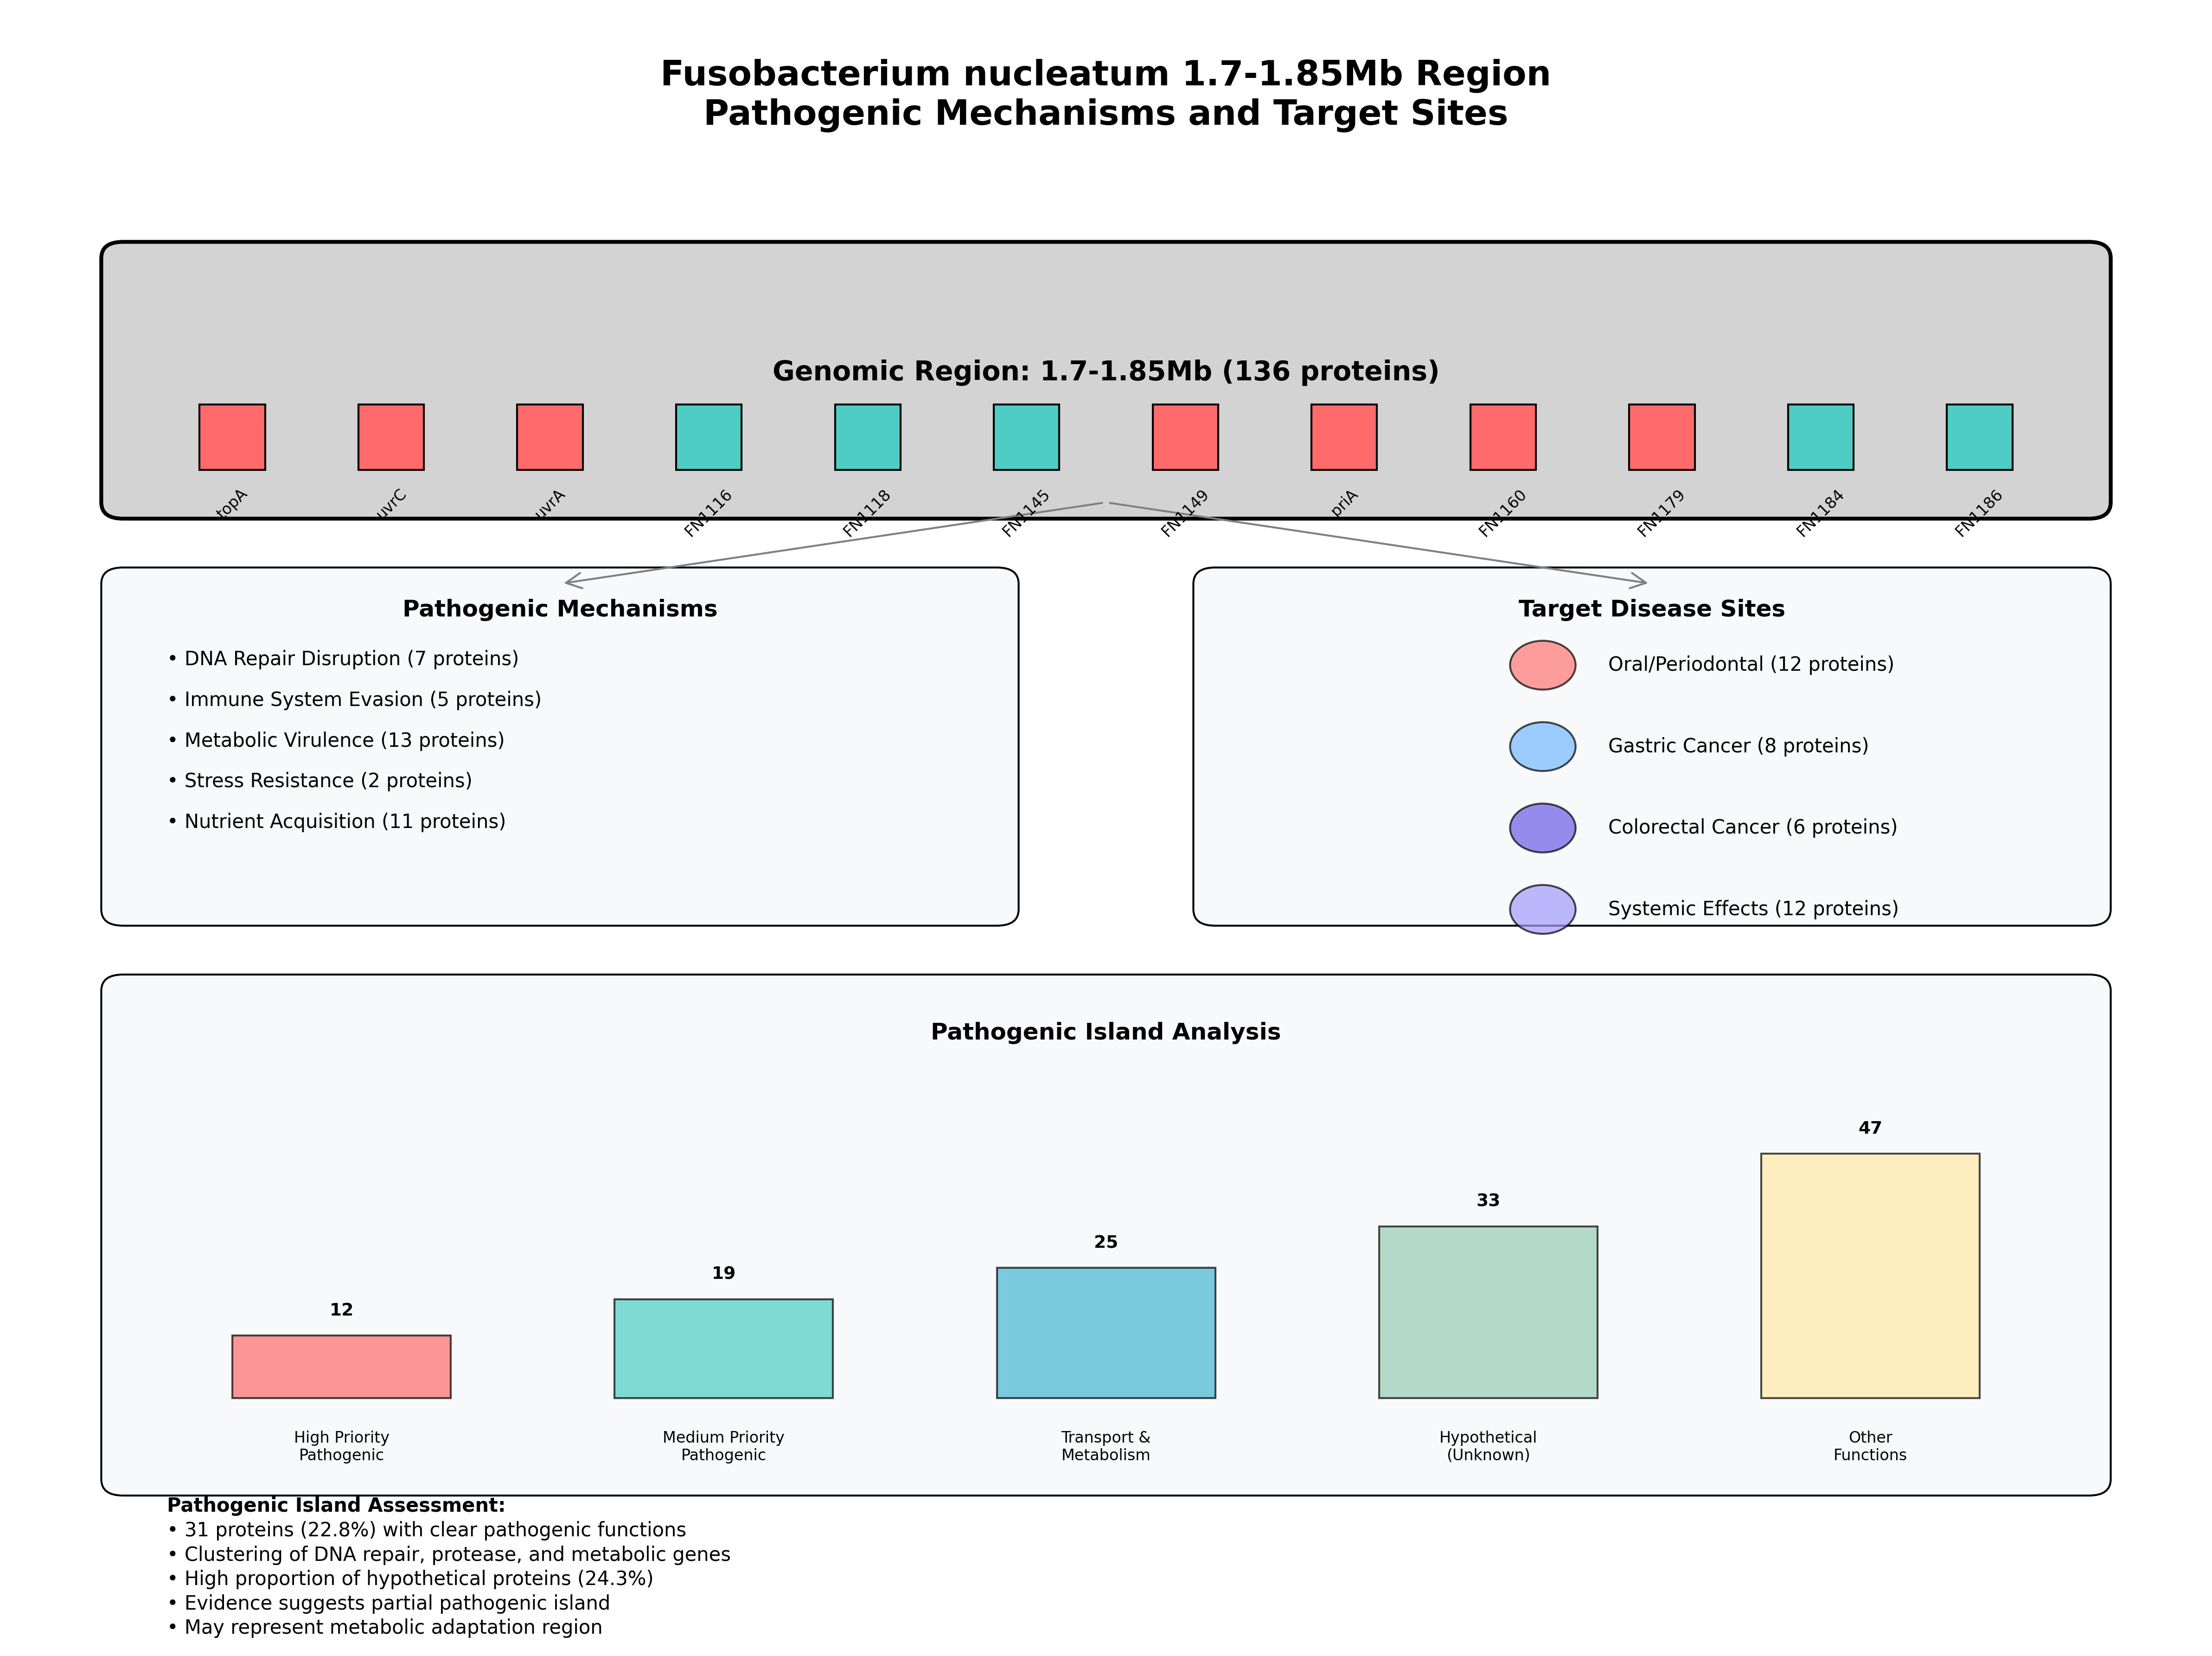

In [35]:
# Now let's create the visualization diagram similar to the reference image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Arrow
import numpy as np

# Set up the figure with high DPI for publication quality
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 12), dpi=300)

# Define colors for different categories
colors = {
    'DNA_repair': '#FF6B6B',      # Red
    'Proteases': '#4ECDC4',       # Teal
    'Metabolic': '#45B7D1',       # Blue
    'Transport': '#96CEB4',       # Green
    'Stress': '#FFEAA7',          # Yellow
    'Unknown': '#DDA0DD',         # Plum
    'Oral': '#FF7675',            # Light red
    'Gastric': '#74B9FF',         # Light blue
    'Colorectal': '#6C5CE7',      # Purple
    'Systemic': '#A29BFE'         # Light purple
}

# Title
ax.text(0.5, 0.95, 'Fusobacterium nucleatum 1.7-1.85Mb Region\nPathogenic Mechanisms and Target Sites', 
        horizontalalignment='center', verticalalignment='center', 
        fontsize=18, fontweight='bold', transform=ax.transAxes)

# Create main sections
sections = {
    'genomic_region': {'x': 0.05, 'y': 0.7, 'width': 0.9, 'height': 0.15},
    'pathogenic_mechanisms': {'x': 0.05, 'y': 0.45, 'width': 0.4, 'height': 0.2},
    'target_sites': {'x': 0.55, 'y': 0.45, 'width': 0.4, 'height': 0.2},
    'protein_distribution': {'x': 0.05, 'y': 0.1, 'width': 0.9, 'height': 0.3}
}

# Draw genomic region representation
genomic_box = FancyBboxPatch((sections['genomic_region']['x'], sections['genomic_region']['y']), 
                            sections['genomic_region']['width'], sections['genomic_region']['height'],
                            boxstyle="round,pad=0.01", facecolor='lightgray', edgecolor='black', linewidth=2)
ax.add_patch(genomic_box)

ax.text(0.5, 0.775, 'Genomic Region: 1.7-1.85Mb (136 proteins)', 
        horizontalalignment='center', fontsize=14, fontweight='bold', transform=ax.transAxes)

# Add gene representation
gene_positions = np.linspace(0.1, 0.9, 12)  # Representative genes
for i, pos in enumerate(gene_positions):
    if i < len(high_priority_proteins):
        protein = high_priority_proteins[i]
        color = colors['DNA_repair'] if 'DNA' in ' '.join(protein['Mechanisms']) else colors['Proteases']
        gene_rect = Rectangle((pos-0.015, 0.72), 0.03, 0.04, facecolor=color, edgecolor='black')
        ax.add_patch(gene_rect)
        ax.text(pos, 0.71, protein['Gene_Name'], rotation=45, fontsize=8, ha='center', va='top')


# Pathogenic Mechanisms section
mech_box = FancyBboxPatch((sections['pathogenic_mechanisms']['x'], sections['pathogenic_mechanisms']['y']), 
                         sections['pathogenic_mechanisms']['width'], sections['pathogenic_mechanisms']['height'],
                         boxstyle="round,pad=0.01", facecolor='#F8F9FA', edgecolor='black', linewidth=1)
ax.add_patch(mech_box)

ax.text(0.25, 0.63, 'Pathogenic Mechanisms', horizontalalignment='center', 
        fontsize=12, fontweight='bold', transform=ax.transAxes)

mechanisms_text = [
    '• DNA Repair Disruption (7 proteins)',
    '• Immune System Evasion (5 proteins)',
    '• Metabolic Virulence (13 proteins)',
    '• Stress Resistance (2 proteins)',
    '• Nutrient Acquisition (11 proteins)'
]

for i, text in enumerate(mechanisms_text):
    ax.text(0.07, 0.6 - i*0.025, text, fontsize=10, transform=ax.transAxes)

# Target Sites section
sites_box = FancyBboxPatch((sections['target_sites']['x'], sections['target_sites']['y']), 
                          sections['target_sites']['width'], sections['target_sites']['height'],
                          boxstyle="round,pad=0.01", facecolor='#F8F9FA', edgecolor='black', linewidth=1)
ax.add_patch(sites_box)

ax.text(0.75, 0.63, 'Target Disease Sites', horizontalalignment='center', 
        fontsize=12, fontweight='bold', transform=ax.transAxes)

# Draw human body outline and disease sites
body_sites = [
    {'name': 'Oral/Periodontal', 'pos': (0.7, 0.6), 'color': colors['Oral'], 'proteins': 12},
    {'name': 'Gastric Cancer', 'pos': (0.7, 0.55), 'color': colors['Gastric'], 'proteins': 8},
    {'name': 'Colorectal Cancer', 'pos': (0.7, 0.5), 'color': colors['Colorectal'], 'proteins': 6},
    {'name': 'Systemic Effects', 'pos': (0.7, 0.45), 'color': colors['Systemic'], 'proteins': 12}
]

for site in body_sites:
    circle = Circle(site['pos'], 0.015, facecolor=site['color'], edgecolor='black', alpha=0.7)
    ax.add_patch(circle)
    ax.text(site['pos'][0] + 0.03, site['pos'][1], f"{site['name']} ({site['proteins']} proteins)", 
            fontsize=10, va='center', transform=ax.transAxes)

# Protein Distribution Analysis
dist_box = FancyBboxPatch((sections['protein_distribution']['x'], sections['protein_distribution']['y']), 
                         sections['protein_distribution']['width'], sections['protein_distribution']['height'],
                         boxstyle="round,pad=0.01", facecolor='#F8F9FA', edgecolor='black', linewidth=1)
ax.add_patch(dist_box)

ax.text(0.5, 0.37, 'Pathogenic Island Analysis', horizontalalignment='center', 
        fontsize=12, fontweight='bold', transform=ax.transAxes)

# Create bar chart for protein categories
categories = ['High Priority\nPathogenic', 'Medium Priority\nPathogenic', 'Transport &\nMetabolism', 
              'Hypothetical\n(Unknown)', 'Other\nFunctions']
counts = [12, 19, 25, 33, 47]
x_positions = np.linspace(0.15, 0.85, len(categories))
bar_width = 0.1

for i, (cat, count, x_pos) in enumerate(zip(categories, counts, x_positions)):
    color_key = list(colors.keys())[i % len(colors)]
    bar_color = colors[color_key]
    
    # Draw bar
    bar_height = count / max(counts) * 0.15
    bar_rect = Rectangle((x_pos - bar_width/2, 0.15), bar_width, bar_height, 
                        facecolor=bar_color, edgecolor='black', alpha=0.7)
    ax.add_patch(bar_rect)
    
    # Add count label
    ax.text(x_pos, 0.15 + bar_height + 0.01, str(count), ha='center', va='bottom', 
            fontsize=9, fontweight='bold', transform=ax.transAxes)
    
    # Add category label
    ax.text(x_pos, 0.13, cat, ha='center', va='top', fontsize=8, 
            transform=ax.transAxes, rotation=0)

# Add pathogenic island assessment
island_text = [
    "Pathogenic Island Assessment:",
    "• 31 proteins (22.8%) with clear pathogenic functions",
    "• Clustering of DNA repair, protease, and metabolic genes",
    "• High proportion of hypothetical proteins (24.3%)",
    "• Evidence suggests partial pathogenic island",
    "• May represent metabolic adaptation region"
]

for i, text in enumerate(island_text):
    weight = 'bold' if i == 0 else 'normal'
    ax.text(0.07, 0.08 - i*0.015, text, fontsize=10, fontweight=weight, transform=ax.transAxes)

# Add arrows connecting sections
arrow1 = patches.FancyArrowPatch((0.5, 0.7), (0.25, 0.65),
                                arrowstyle='->', mutation_scale=20, color='gray')
ax.add_patch(arrow1)

arrow2 = patches.FancyArrowPatch((0.5, 0.7), (0.75, 0.65),
                                arrowstyle='->', mutation_scale=20, color='gray')
ax.add_patch(arrow2)

# Remove axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.savefig(f'fusobacterium_pathogenic_analysis.png', 
            dpi=300, bbox_inches='tight', facecolor='white')


In [ ]:
# ============================================================================
# BLASTP against the UniProt Swiss- Prot database and NCBI non-redundant (nr) protein database
# Quick analysis made base on keyword
#TCode for Blast PAi identified by IslandViewer 4
#366,847 to 372,320
#1,496,613 to 1,523,855
#1,967,193 to 1,999,047
# ============================================================================
#sequence-region AE009951.2 366,847 to 372,320
import pandas as pd

gff_file = "try.GFF3"
output_file = "try_list.xlsx"

data = []
with open(gff_file) as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        attributes = parts[8]
        attr_dict = {}
        for attr in attributes.split(";"):
            if "=" in attr:
                key, value = attr.split("=", 1)
                attr_dict[key] = value
        locus_tag = attr_dict.get("locus_tag", "")
        protein_id = attr_dict.get("protein_id", "")
        product = attr_dict.get("product", "")
        if locus_tag:
            data.append([locus_tag, protein_id, product])

df = pd.DataFrame(data, columns=["locus_tag", "protein_id", "product"])
df.to_excel(output_file, index=False)
print(f"Saved to {output_file}")

#Blast protein in 366,847 to 372,320
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import SeqIO
import pandas as pd
import time

fasta_file = "sequence.txt"
results = []

for record in SeqIO.parse(fasta_file, "fasta"):
    print(f"BLASTing {record.id} ...")
    # Submit BLASTP job to NCBI (may take time and has rate limits)
    result_handle = NCBIWWW.qblast("blastp", "nr", record.seq)
    blast_record = NCBIXML.read(result_handle)
    hit_count = 0
    for alignment in blast_record.alignments:
        for hsp in alignment.hsps:
            results.append({
                "query": record.id,
                "hit_id": alignment.hit_id,
                "hit_def": alignment.hit_def,
                "e_value": hsp.expect,
                "score": hsp.score
            })
            hit_count += 1
            break  # Only first HSP per alignment
        if hit_count >= 3:
            break
    time.sleep(2)  # Be polite to NCBI servers

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("try_top3.csv", index=False)
print("BLAST results saved to try_top3.csv")

#sequence-region AE009951.2 1,496,613 to 1,523,855
import pandas as pd

gff_file = "1496613_1523855.GFF3"
output_file = "1496613_1523855_list.xlsx"

data = []
with open(gff_file) as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        attributes = parts[8]
        attr_dict = {}
        for attr in attributes.split(";"):
            if "=" in attr:
                key, value = attr.split("=", 1)
                attr_dict[key] = value
        locus_tag = attr_dict.get("locus_tag", "")
        protein_id = attr_dict.get("protein_id", "")
        product = attr_dict.get("product", "")
        if locus_tag:
            data.append([locus_tag, protein_id, product])

df = pd.DataFrame(data, columns=["locus_tag", "protein_id", "product"])
df.to_excel(output_file, index=False)
print(f"Saved to {output_file}")

#Blast protein in 1,496,613 to 1,523,855
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import SeqIO
import pandas as pd
import time

fasta_file = "1496613_1523855_protein.txt"
results = []

for record in SeqIO.parse(fasta_file, "fasta"):
    print(f"BLASTing {record.id} ...")
    # Submit BLASTP job to NCBI (may take time and has rate limits)
    result_handle = NCBIWWW.qblast("blastp", "nr", record.seq)
    blast_record = NCBIXML.read(result_handle)
    hit_count = 0
    for alignment in blast_record.alignments:
        for hsp in alignment.hsps:
            results.append({
                "query": record.id,
                "hit_id": alignment.hit_id,
                "hit_def": alignment.hit_def,
                "e_value": hsp.expect,
                "score": hsp.score
            })
            hit_count += 1
            break  # Only first HSP per alignment
        if hit_count >= 3:
            break
    time.sleep(2)  # Be polite to NCBI servers

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("1496613_1523855_protein_top3.csv", index=False)
print("BLAST results saved to 1496613_1523855_protein_top3.csv")

#sequence-region AE009951.2 1,967,193 to 1,999,047
import pandas as pd

gff_file = "1967193_1999047.GFF3"
output_file = "1967193_1999047_list.xlsx"

data = []
with open(gff_file) as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        attributes = parts[8]
        attr_dict = {}
        for attr in attributes.split(";"):
            if "=" in attr:
                key, value = attr.split("=", 1)
                attr_dict[key] = value
        locus_tag = attr_dict.get("locus_tag", "")
        protein_id = attr_dict.get("protein_id", "")
        product = attr_dict.get("product", "")
        if locus_tag:
            data.append([locus_tag, protein_id, product])

df = pd.DataFrame(data, columns=["locus_tag", "protein_id", "product"])
df.to_excel(output_file, index=False)
print(f"Saved to {output_file}")

#Blast protein in 1,967,193 to 1,999,047
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import SeqIO
import pandas as pd
import time

fasta_file = "1967193_1999047_protein.txt"
results = []

for record in SeqIO.parse(fasta_file, "fasta"):
    print(f"BLASTing {record.id} ...")
    # Submit BLASTP job to NCBI (may take time and has rate limits)
    result_handle = NCBIWWW.qblast("blastp", "nr", record.seq)
    blast_record = NCBIXML.read(result_handle)
    hit_count = 0
    for alignment in blast_record.alignments:
        for hsp in alignment.hsps:
            results.append({
                "query": record.id,
                "hit_id": alignment.hit_id,
                "hit_def": alignment.hit_def,
                "e_value": hsp.expect,
                "score": hsp.score
            })
            hit_count += 1
            break  # Only first HSP per alignment
        if hit_count >= 3:
            break
    time.sleep(2)  # Be polite to NCBI servers

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("1967193_1999047_protein_top3.csv", index=False)
print("BLAST results saved to 1967193_1999047_protein_top3.csv")

In [ ]:
# Generating visualize diagram base on keyword, and some modified
#not really used in the main study, mostly as a reference
#something to think of

import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel('366,847_372,320_list.xlsx')

# 1. Biological Function Category
def categorize_function(decision): #manual decision, so could have bias, this is just first imperssion
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Hypothetical/Unknown'
    elif 'transposase' in decision.lower():
        return 'Transposase'
    elif 'ribosomal' in decision.lower():
        return 'Ribosomal Protein'
    elif 'oxidoreductase' in decision.lower() or 'thioesterase' in decision.lower():
        return 'Enzyme'
    elif 'metallothionein' in decision.lower():
        return 'Metal Binding Protein'
    elif 'hemolysin' in decision.lower():
        return 'Toxin'
    else:
        return 'Other'

df['Function_Category'] = df['Decision'].apply(categorize_function)
func_counts = df['Function_Category'].value_counts()

plt.figure(figsize=(8,5))
func_counts.plot(kind='bar', color='skyblue')
plt.title('Biological Function Category (from Decision column)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in the Decision column.")

# 2. Pathogen/Cancer Potential
def categorize_pathogen_cancer(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower() or 'toxin' in decision.lower():
        return 'Pathogen Potential'
    elif 'transposase' in decision.lower():
        return 'Mobile Element'
    elif 'cancer' in decision.lower():
        return 'Cancer Potential'
    else:
        return 'Other'

df['Pathogen_Cancer'] = df['Decision'].apply(categorize_pathogen_cancer)
pc_counts = df['Pathogen_Cancer'].value_counts()

plt.figure(figsize=(8,5))
pc_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral','gold','lightgreen','lightblue'])
plt.title('Pathogen/Cancer Potential (from Decision column)')
plt.ylabel('')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by presence of keywords ('hemolysin', 'toxin', 'cancer', 'transposase') in Decision column.")

# 3. Likely Site of Action
def categorize_site(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower():
        return 'Blood/Cell Membrane'
    elif 'transposase' in decision.lower():
        return 'Genome'
    elif 'ribosomal' in decision.lower():
        return 'Cytoplasm'
    elif 'lipoprotein' in decision.lower():
        return 'Membrane'
    else:
        return 'Other'

df['Site'] = df['Decision'].apply(categorize_site)
site_counts = df['Site'].value_counts()

plt.figure(figsize=(8,5))
site_counts.plot(kind='bar', color='orchid')
plt.title('Likely Site of Action (from Decision column)')
plt.xlabel('Site')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in Decision column to infer likely cellular location or site of action.")

In [ ]:
# same for remaing two PAI
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel('1967193_1999047_list.xlsx')

# 1. Biological Function Category
def categorize_function(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Hypothetical/Unknown'
    elif 'transposase' in decision.lower():
        return 'Transposase'
    elif 'ribosomal' in decision.lower():
        return 'Ribosomal Protein'
    elif 'oxidoreductase' in decision.lower() or 'thioesterase' in decision.lower():
        return 'Enzyme'
    elif 'metallothionein' in decision.lower():
        return 'Metal Binding Protein'
    elif 'hemolysin' in decision.lower():
        return 'Toxin'
    else:
        return 'Other'

df['Function_Category'] = df['Decision'].apply(categorize_function)
func_counts = df['Function_Category'].value_counts()

plt.figure(figsize=(8,5))
func_counts.plot(kind='bar', color='skyblue')
plt.title('Biological Function Category (from Decision column)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in the Decision column.")

# 2. Pathogen/Cancer Potential
def categorize_pathogen_cancer(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower() or 'toxin' in decision.lower():
        return 'Pathogen Potential'
    elif 'transposase' in decision.lower():
        return 'Mobile Element'
    elif 'cancer' in decision.lower():
        return 'Cancer Potential'
    else:
        return 'Other'

df['Pathogen_Cancer'] = df['Decision'].apply(categorize_pathogen_cancer)
pc_counts = df['Pathogen_Cancer'].value_counts()

plt.figure(figsize=(8,5))
pc_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral','gold','lightgreen','lightblue'])
plt.title('Pathogen/Cancer Potential (from Decision column)')
plt.ylabel('')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by presence of keywords ('hemolysin', 'toxin', 'cancer', 'transposase') in Decision column.")

# 3. Likely Site of Action
def categorize_site(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower():
        return 'Blood/Cell Membrane'
    elif 'transposase' in decision.lower():
        return 'Genome'
    elif 'ribosomal' in decision.lower():
        return 'Cytoplasm'
    elif 'lipoprotein' in decision.lower():
        return 'Membrane'
    else:
        return 'Other'

df['Site'] = df['Decision'].apply(categorize_site)
site_counts = df['Site'].value_counts()

plt.figure(figsize=(8,5))
site_counts.plot(kind='bar', color='orchid')
plt.title('Likely Site of Action (from Decision column)')
plt.xlabel('Site')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in Decision column to infer likely cellular location or site of action.")

import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel('1496613_1523855_list.xlsx')

# 1. Biological Function Category
def categorize_function(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Hypothetical/Unknown'
    elif 'transposase' in decision.lower():
        return 'Transposase'
    elif 'ribosomal' in decision.lower():
        return 'Ribosomal Protein'
    elif 'oxidoreductase' in decision.lower() or 'thioesterase' in decision.lower():
        return 'Enzyme'
    elif 'metallothionein' in decision.lower():
        return 'Metal Binding Protein'
    elif 'hemolysin' in decision.lower():
        return 'Toxin'
    else:
        return 'Other'

df['Function_Category'] = df['Decision'].apply(categorize_function)
func_counts = df['Function_Category'].value_counts()

plt.figure(figsize=(8,5))
func_counts.plot(kind='bar', color='skyblue')
plt.title('Biological Function Category (from Decision column)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in the Decision column.")

# 2. Pathogen/Cancer Potential
def categorize_pathogen_cancer(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower() or 'toxin' in decision.lower():
        return 'Pathogen Potential'
    elif 'transposase' in decision.lower():
        return 'Mobile Element'
    elif 'cancer' in decision.lower():
        return 'Cancer Potential'
    else:
        return 'Other'

df['Pathogen_Cancer'] = df['Decision'].apply(categorize_pathogen_cancer)
pc_counts = df['Pathogen_Cancer'].value_counts()

plt.figure(figsize=(8,5))
pc_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral','gold','lightgreen','lightblue'])
plt.title('Pathogen/Cancer Potential (from Decision column)')
plt.ylabel('')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by presence of keywords ('hemolysin', 'toxin', 'cancer', 'transposase') in Decision column.")

# 3. Likely Site of Action
def categorize_site(decision):
    if pd.isna(decision) or decision.lower() == 'unknown':
        return 'Unknown'
    elif 'hemolysin' in decision.lower():
        return 'Blood/Cell Membrane'
    elif 'transposase' in decision.lower():
        return 'Genome'
    elif 'ribosomal' in decision.lower():
        return 'Cytoplasm'
    elif 'lipoprotein' in decision.lower():
        return 'Membrane'
    else:
        return 'Other'

df['Site'] = df['Decision'].apply(categorize_site)
site_counts = df['Site'].value_counts()

plt.figure(figsize=(8,5))
site_counts.plot(kind='bar', color='orchid')
plt.title('Likely Site of Action (from Decision column)')
plt.xlabel('Site')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Parameters: Categorized by keyword matching in Decision column to infer likely cellular location or site of action.")

In [ ]:
#!/usr/bin/env python3
# ============================================================================
# Complete Virulence Factor Analysis Pipeline for F. nucleatum Genomic Islands
#Targeted BLASTP searches against
#two curated virulence factor databases.

#performs comprehensive virulence factor analysis using 
# databases (VFDB + VICTORS) for all genomic regions of interest.

# Requirements:
# - Python 3.7+
# - Biopython: pip install biopython
# - pandas: pip install pandas
# - NCBI BLAST+: brew install blast (Mac)
# -VPN!!! Otherwise ERROR: VICTORS download failed. Why? No idea, but it work now.

# Acknowledgments:
# Thank for deepseek debug my code, thank for copolit and biomni lab help me to write this code 
# (Promote I give are I want to run Blast on virlence database, I mean those bacteria focus. I have 3 list of protein, I want to check homolog in VFDB and VICTORS.
# I have protein ID. I only have 2GB storage space), 
# thank for all the people who have contributed to the databases and tools used in this pipeline.
# ============================================================================

import os
import sys
import subprocess
import time
import gzip
import shutil
from io import StringIO
from pathlib import Path



# Your email for NCBI Entrez (required)
ENTREZ_EMAIL = "ztian12@jh.edu"  #Please don't use my email, put your email here

# E-value threshold for BLAST
EVALUE_THRESHOLD = 1e-10

# Protein IDs for each genomic region
# Format: {region_name: [list of protein accessions]}
#basically list of protein I am checking

PROTEIN_IDS = {
    
    "PAI1": [
        "AAL93977.1",  # FN1878 - unknown
        "AAL93978.1",  # FN1879 - SSU ribosomal protein S20P
        "AAL93979.1",  # FN1880 - nitroreductase
        "AAL93980.1",  # FN1881 - acyl-CoA thioesterase
        "AAL93981.1",  # FN1882 - unknown
        "AAL93982.1",  # FN1883 - transposase
        "AAL93983.1",  # FN1884 - Metallothionein
        "AAL93984.1",  # FN1885 - Hemolysin III (KEY VIRULENCE FACTOR)
        "AAL93985.1",  # FN1886 - unknown
        "AAL93986.1",  # FN1887 - Transposase
    ],
   
    "PAI2": [
        "AAL95030.1",  # FN0834
        "AAL95031.1",  # FN0835
        "AAL95032.1",  # FN0836
        "AAL95033.1",  # FN0837 - integrase
        "AAL95034.1",  # FN0838
        "AAL95035.1",  # FN0839
        "AAL95036.1",  # FN0840 - Transposase
        "AAL95037.1",  # FN0841 - IS3 transposase
        "AAL95038.1",  # FN0842
        "AAL95039.1",  # FN0843
        "AAL95040.1",  # FN0844
        "AAL95041.1",  # FN0845 - RiboL-PSP-HEPN (toxin)
        "AAL95042.1",  # FN0846 - YwqK antitoxin
        "AAL95043.1",  # FN0847
        "AAL95044.1",  # FN0848
        "AAL95045.1",  # FN0849 - bioF (biotin synthesis)
        "AAL95046.1",  # FN0850 - BioG
        "AAL95047.1",  # FN0851 - BioC
        "AAL95048.1",  # FN0852 - hydrolase
        "AAL95049.1",  # FN0853 - glgA (glycogen synthase)
        "AAL95050.1",  # FN0854 - GlgD
        "AAL95051.1",  # FN0855 - glucose-1-phosphate adenylyltransferase
        "AAL95052.1",  # FN0856 - glucan branching enzyme
        "AAL95053.1",  # FN0857 - Glycogen phosphorylase
        "AAL95054.1",  # FN0858 - glucanotransferase
        "AAL95055.1",  # FN0859 - Lipoprotein
        "AAL95056.1",  # FN0860
        "AAL95057.1",  # FN0861
        "AAL95058.1",  # FN0862
        "AAL95059.1",  # FN0863
        "AAL95060.1",  # FN0864
        "AAL95061.1",  # FN0865 - Outer membrane protein
    ],

    "PAI3": [
        "AAL95509.1",  # FN1313 - oppA
        "AAL95510.1",  # FN1314
        "AAL95511.1",  # FN1315
        "AAL95512.1",  # FN1316
        "AAL95513.1",  # FN1317 - sigma-70
        "AAL95514.1",  # FN1318 - rpoD/sigA (KEY: virulence regulation)
        "AAL95515.1",  # FN1319 - DNA primase
        "AAL95516.1",  # FN1320
        "AAL95517.1",  # FN1321 - pilR (KEY: Type IV pili, adherence)
        "AAL95518.1",  # FN1322 - mucP (KEY: biofilm)
        "AAL95519.1",  # FN1323
        "AAL95520.1",  # FN1324
        "AAL95521.1",  # FN1325 - cpsB/cdsA (KEY: capsule)
        "AAL95522.1",  # FN1326 - cpsA/uppS (KEY: capsule)
        "AAL95523.1",  # FN1327
        "AAL95524.1",  # FN1328
        "AAL95525.1",  # FN1329
        "AAL95526.1",  # FN1330
        "AAL95527.1",  # FN1331
        "AAL95528.1",  # FN1332
        "AAL95529.1",  # FN1333
        "AAL95530.1",  # FN1334 - amidase
        "AAL95531.1",  # FN1335
        "AAL95532.1",  # FN1336
        "AAL95533.1",  # FN1337
        "AAL95534.1",  # FN1338
        "AAL95535.1",  # FN1339 - transposase
        "AAL95536.1",  # FN1340 - Glutamyl-tRNA synthetase
        "AAL95537.1",  # FN1341
        "AAL95538.1",  # FN1342
        "AAL95539.1",  # FN1343
        "AAL95540.1",  # FN1344
        "AAL95541.1",  # FN1345
    ],
}

# Add Any region if you have those protein IDs
# PROTEIN_IDS["Region"] = [
#     # Add protein IDs here
# ]

#generate output file
RESULTS_DIR = Path("results")
DB_DIR = Path("databases")
SEQUENCES_DIR = Path("sequences")

def setup_directories():
    """Create output directories"""
    for d in [RESULTS_DIR, DB_DIR, SEQUENCES_DIR]:
        d.mkdir(exist_ok=True)
    print(f"Directories created: results/, databases/, sequences/")

def download_vfdb():
    """Download VFDB setA database"""
    vfdb_gz = DB_DIR / "VFDB_setA_pro.fas.gz"
    vfdb_fasta = DB_DIR / "VFDB_setA_pro.fas"

    if vfdb_fasta.exists():
        print("VFDB already downloaded")
        return vfdb_fasta

    print("Downloading VFDB...")
    url = "http://www.mgc.ac.cn/VFs/Down/VFDB_setA_pro.fas.gz"
    result = subprocess.run(['wget', '--user-agent=Mozilla/5.0', '-q', '-O', str(vfdb_gz), url])

    if result.returncode != 0:
        result = subprocess.run(['curl', '-L', '-A', 'Mozilla/5.0', '-o', str(vfdb_gz), url])

    if vfdb_gz.exists() and vfdb_gz.stat().st_size > 1000:
        with gzip.open(vfdb_gz, 'rb') as f_in:
            with open(vfdb_fasta, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        count = sum(1 for line in open(vfdb_fasta) if line.startswith('>'))
        print(f"VFDB downloaded: {count} sequences")
        return vfdb_fasta
    else:
        print("ERROR: VFDB download failed")
        return None

def download_victors():
    """Download VICTORS database"""
    victors_fasta = DB_DIR / "victors_proteins.fasta"

    if victors_fasta.exists():
        print("VICTORS already downloaded")
        return victors_fasta

    print("Downloading VICTORS...")
    url = "https://phidias.us/victors/downloads/gen_downloads_protein.php"
    result = subprocess.run(['curl', '-L', '-o', str(victors_fasta), '--user-agent', 'Mozilla/5.0', url])

    if victors_fasta.exists() and victors_fasta.stat().st_size > 1000:
        # Verify it's FASTA
        with open(victors_fasta) as f:
            first_line = f.readline()
        if first_line.startswith('>'):
            count = sum(1 for line in open(victors_fasta) if line.startswith('>'))
            print(f"VICTORS downloaded: {count} sequences")
            return victors_fasta

    print("ERROR: VICTORS download failed")
    return None

def create_blast_db(fasta_path, db_name):
    """Create BLAST database"""
    db_path = DB_DIR / db_name

    if (DB_DIR / f"{db_name}.pin").exists():
        print(f"BLAST database {db_name} already exists")
        return db_path

    print(f"Creating BLAST database: {db_name}...")
    result = subprocess.run([
        'makeblastdb', '-in', str(fasta_path), '-dbtype', 'prot',
        '-out', str(db_path), '-title', db_name
    ], capture_output=True, text=True)

    if result.returncode == 0:
        print(f"Database {db_name} created")
        return db_path
    else:
        print(f"ERROR: {result.stderr}")
        return None

def fetch_sequences():
    """Fetch protein sequences from NCBI"""
    query_fasta = SEQUENCES_DIR / "all_proteins.fasta"

    if query_fasta.exists():
        print("Sequences already fetched")
        return query_fasta

    print("Fetching sequences from NCBI...")

    all_sequences = []
    for region, protein_ids in PROTEIN_IDS.items():
        print(f"  Fetching {region}: {len(protein_ids)} proteins...")

        batch_size = 50
        for i in range(0, len(protein_ids), batch_size):
            batch = protein_ids[i:i+batch_size]
            try:
                handle = Entrez.efetch(db="protein", id=",".join(batch),
                                       rettype="fasta", retmode="text")
                fasta_data = handle.read()
                handle.close()

                for record in SeqIO.parse(StringIO(fasta_data), "fasta"):
                    all_sequences.append((region, record))

                time.sleep(0.5)
            except Exception as e:
                print(f"    Warning: {e}")

    # Save with region tags
    with open(query_fasta, 'w') as f:
        for region, seq in all_sequences:
            f.write(f">{region}|{seq.id}\n{str(seq.seq)}\n")

    print(f"Saved {len(all_sequences)} sequences")
    return query_fasta

def run_blast(query_fasta, db_path, db_name):
    """Run BLASTP against a database"""
    output_file = RESULTS_DIR / f"{db_name}_blast_results.tsv"

    print(f"Running BLAST against {db_name}...")
    result = subprocess.run([
        'blastp', '-query', str(query_fasta), '-db', str(db_path),
        '-out', str(output_file),
        '-outfmt', '6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore stitle',
        '-evalue', str(EVALUE_THRESHOLD), '-max_target_seqs', '5', '-num_threads', '4'
    ], capture_output=True, text=True)

    if result.returncode == 0:
        hits = sum(1 for _ in open(output_file))
        print(f"  {hits} hits found")
        return output_file
    else:
        print(f"ERROR: {result.stderr}")
        return None

def parse_vfdb_annotation(stitle):
    """Parse VFDB annotation format"""
    try:
        parts = stitle.split(')')
        gene = parts[1].strip().split()[0].strip('(') if len(parts) > 1 else ''
        if '[' in stitle:
            bracket_parts = stitle.split('[')
            vf_category = bracket_parts[1].split(']')[0] if len(bracket_parts) >= 2 else ''
            organism = bracket_parts[2].split(']')[0] if len(bracket_parts) >= 3 else ''
        else:
            vf_category, organism = '', ''
        return gene, vf_category, organism
    except:
        return '', '', ''

def parse_victors_annotation(stitle):
    """Parse VICTORS annotation format"""
    try:
        parts = stitle.split('|')
        desc = parts[-1].strip()
        if '[' in desc:
            organism = desc.split('[')[1].split(']')[0]
            desc = desc.split('[')[0].strip()
        else:
            organism = ''
        return desc, organism
    except:
        return stitle, ''

def analyze_results():
    """Combine and analyze results from all databases"""
    columns = ['query', 'subject', 'pident', 'length', 'mismatch', 'gapopen',
               'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 'stitle']

    all_results = []

    # Load VFDB results
    vfdb_file = RESULTS_DIR / "vfdb_blast_results.tsv"
    if vfdb_file.exists():
        vfdb_df = pd.read_csv(vfdb_file, sep='\t', names=columns)
        if not vfdb_df.empty:
            vfdb_df['database'] = 'VFDB'
            vfdb_df['region'] = vfdb_df['query'].apply(lambda x: x.split('|')[0])
            vfdb_df[['gene', 'vf_category', 'organism']] = vfdb_df['stitle'].apply(
                lambda x: pd.Series(parse_vfdb_annotation(x)))
            all_results.append(vfdb_df)
        else:
            print("VFDB BLAST result is empty (no hits).")

    # Load VICTORS results
    victors_file = RESULTS_DIR / "victors_blast_results.tsv"
    if victors_file.exists():
        victors_df = pd.read_csv(victors_file, sep='\t', names=columns)
        if not victors_df.empty:
            victors_df['database'] = 'VICTORS'
            victors_df['region'] = victors_df['query'].apply(lambda x: x.split('|')[0])
            victors_df[['description', 'organism']] = victors_df['stitle'].apply(
                lambda x: pd.Series(parse_victors_annotation(x)))
            victors_df['gene'] = victors_df['description'].apply(lambda x: x.split()[0] if x else '')
            victors_df['vf_category'] = ''
            all_results.append(victors_df)
        else:
            print("VICTORS BLAST result is empty (no hits).")

    if not all_results:
        print("No results to analyze")
        return

    combined = pd.concat(all_results, ignore_index=True)

    # Get best hit per protein per database
    best_hits = combined.loc[combined.groupby(['query', 'database'])['evalue'].idxmin()] # this look like a bug 
    #a protein like FN0849/bioF that hits both databases produces two separate rows — one with database='VFDB' and one with database='VICTORS'
    # maybe I should try to merge them to make the excel cleaner
    # but that require a new function. 
    # so I like my original code. Thank you

    # Summary
    print("\n" + "=" * 70)
    print("VIRULENCE FACTOR ANALYSIS SUMMARY")
    print("=" * 70)

    for region in sorted(combined['region'].unique()):
        region_hits = best_hits[best_hits['region'] == region]
        unique_proteins = region_hits['query'].nunique()

        print(f"\n### {region}: {unique_proteins} proteins with VF hits ###")

        for _, row in region_hits.drop_duplicates('query').iterrows():
            protein_id = row['query'].split('|')[1]
            print(f"  {protein_id}: {row['gene']} ({row['database']})")
            if row['vf_category']:
                print(f"    Category: {row['vf_category']}")
            print(f"    Identity: {row['pident']:.1f}%, E-value: {row['evalue']:.2e}")

    # Save combined results
    output_file = RESULTS_DIR / "combined_vf_analysis.csv"
    best_hits.to_csv(output_file, index=False)
    print(f"\nResults saved to {output_file}")

    #Best hit per protein per database
    #the code runs groupby(['query', 'database'])['evalue'].idxmin() to keep only the s
    #ingle best-scoring hit for each protein in each database

    # Create summary table
    summary = best_hits.groupby('region').agg({
        'query': 'nunique',
        'database': lambda x: ', '.join(sorted(set(x)))
    }).reset_index()
    summary.columns = ['Region', 'Proteins_with_VF_hits', 'Databases']

    summary_file = RESULTS_DIR / "summary_by_region.csv"
    summary.to_csv(summary_file, index=False)
    print(f"Summary saved to {summary_file}")

def main():
    print("=" * 70)
    print("F. nucleatum Virulence Factor Analysis Pipeline")
    print("=" * 70)

    setup_directories()

    # Download databases
    vfdb_fasta = download_vfdb()
    victors_fasta = download_victors()

    # Create BLAST databases
    if vfdb_fasta:
        vfdb_db = create_blast_db(vfdb_fasta, "vfdb")
    if victors_fasta:
        victors_db = create_blast_db(victors_fasta, "victors")

    # Fetch query sequences
    query_fasta = fetch_sequences()

    # Run BLAST
    if vfdb_fasta and query_fasta:
        run_blast(query_fasta, vfdb_db, "vfdb") #All raw BLAST hits against VFDB (up to 5 hits per protein, -max_target_seqs 5)
    if victors_fasta and query_fasta:
        run_blast(query_fasta, victors_db, "victors") #All raw BLAST hits against VICTORS (up to 5 hits per protein)

    # Analyze results
    analyze_results()

    print("\n" + "=" * 70)
    print("Analysis complete!")
    print("=" * 70)

if __name__ == "__main__":
    main()


In [ ]:
# ============================================================================
# STRING Protein Interaction Network Analysis
#This script queries the STRING database API to get protein-protein
# interaction networks for F. nucleatum proteins.

# Requirements:
# - requests: pip install requests
# - pandas: pip install pandas
# - networkx: pip install networkx (optional, for network analysis)

# Usage:
#     python string_analysis.py


#!/usr/bin/env python3
# ============================================================================



import requests
import pandas as pd
import time
import json
from pathlib import Path

# STRING API base URL
STRING_API = "https://string-db.org/api"

# F. nucleatum ATCC 25586 taxonomy ID
TAXON_ID = 190304

# Output directory
OUTPUT_DIR = Path("results/string")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_string_ids(protein_names, species=TAXON_ID):
    """Map protein names/IDs to STRING identifiers"""
    url = f"{STRING_API}/json/get_string_ids"

    params = {
        "identifiers": "\n".join(protein_names),
        "species": species,
        "limit": 1,
        "caller_identity": "fusobacterium_analysis"
    }

    response = requests.post(url, data=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return []

def get_interaction_network(string_ids, required_score=400):
    """Get protein-protein interaction network from STRING"""
    url = f"{STRING_API}/json/network"

    params = {
        "identifiers": "\n".join(string_ids),
        "species": TAXON_ID,
        "required_score": required_score,
        "caller_identity": "fusobacterium_analysis"
    }

    response = requests.post(url, data=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return []

def get_functional_enrichment(string_ids):
    """Get functional enrichment analysis from STRING"""
    url = f"{STRING_API}/json/enrichment"

    params = {
        "identifiers": "\n".join(string_ids),
        "species": TAXON_ID,
        "caller_identity": "fusobacterium_analysis"
    }

    response = requests.post(url, data=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return []

def get_network_image(string_ids, filename):
    """Download network image from STRING"""
    url = f"{STRING_API}/image/network"

    params = {
        "identifiers": "\n".join(string_ids),
        "species": TAXON_ID,
        "required_score": 400,
        "network_flavor": "confidence",
        "caller_identity": "fusobacterium_analysis"
    }

    response = requests.post(url, data=params)

    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Network image saved to {filename}")
    else:
        print(f"Error downloading image: {response.status_code}")

def analyze_region(region_name, gene_names):
    """Analyze a single genomic region"""
    print(f"\n{'='*60}")
    print(f"Analyzing {region_name}")
    print(f"{'='*60}")

    # Get STRING IDs
    print(f"Mapping {len(gene_names)} proteins to STRING...")
    string_mapping = get_string_ids(gene_names)
    time.sleep(1)  # Rate limiting

    if not string_mapping:
        print("No STRING mappings found")
        return None

    string_ids = [item['stringId'] for item in string_mapping]
    print(f"Found {len(string_ids)} STRING IDs")

    # Get interaction network
    print("Fetching interaction network...")
    interactions = get_interaction_network(string_ids)
    time.sleep(1)

    if interactions:
        print(f"Found {len(interactions)} interactions")

        # Save interactions
        interactions_df = pd.DataFrame(interactions)
        interactions_df.to_csv(OUTPUT_DIR / f"{region_name}_interactions.csv", index=False)

    # Get functional enrichment
    print("Fetching functional enrichment...")
    enrichment = get_functional_enrichment(string_ids)
    time.sleep(1)

    if enrichment:
        enrichment_df = pd.DataFrame(enrichment)
        enrichment_df.to_csv(OUTPUT_DIR / f"{region_name}_enrichment.csv", index=False)

        # Print top enriched terms
        print("\nTop enriched terms:")
        for _, row in enrichment_df.head(5).iterrows():
            print(f"  {row.get('term', 'N/A')}: p={row.get('p_value', 'N/A'):.2e}")

    # Download network image
    print("Downloading network image...")
    get_network_image(string_ids, OUTPUT_DIR / f"{region_name}_network.png")

    return {
        'region': region_name,
        'proteins': len(gene_names),
        'string_ids': len(string_ids),
        'interactions': len(interactions) if interactions else 0
    }

def main():
    # Import protein IDs from config
    try:
        from config import PROTEIN_IDS
    except ImportError:
        print("ERROR: config.py not found. Create it with PROTEIN_IDS dictionary.")
        return

    print("STRING Protein Interaction Analysis")
    print("=" * 60)

    results = []

    for region, protein_ids in PROTEIN_IDS.items():
        # Use locus tags if available, otherwise use accessions
        # STRING works better with gene names/locus tags
        result = analyze_region(region, protein_ids)
        if result:
            results.append(result)
        time.sleep(2)  # Rate limiting between regions

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)

    summary_df = pd.DataFrame(results)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(OUTPUT_DIR / "string_summary.csv", index=False)

    print(f"\nResults saved to {OUTPUT_DIR}/")

if __name__ == "__main__":
    main()


Adding exchange reaction EX_13ppd_e with default bounds for boundary metabolite: 13ppd_e.
Adding exchange reaction EX_15dap_e with default bounds for boundary metabolite: 15dap_e.
Adding exchange reaction EX_2ameph_e with default bounds for boundary metabolite: 2ameph_e.
Adding exchange reaction EX_2hxmp_e with default bounds for boundary metabolite: 2hxmp_e.
Adding exchange reaction EX_2m35mdntha_e with default bounds for boundary metabolite: 2m35mdntha_e.
Adding exchange reaction EX_2obut_e with default bounds for boundary metabolite: 2obut_e.
Adding exchange reaction EX_2pglyc_e with default bounds for boundary metabolite: 2pglyc_e.
Adding exchange reaction EX_35dnta_e with default bounds for boundary metabolite: 35dnta_e.
Adding exchange reaction EX_3mb_e with default bounds for boundary metabolite: 3mb_e.
Adding exchange reaction EX_4hba_e with default bounds for boundary metabolite: 4hba_e.
Adding exchange reaction EX_4hbald_e with default bounds for boundary metabolite: 4hbald_e

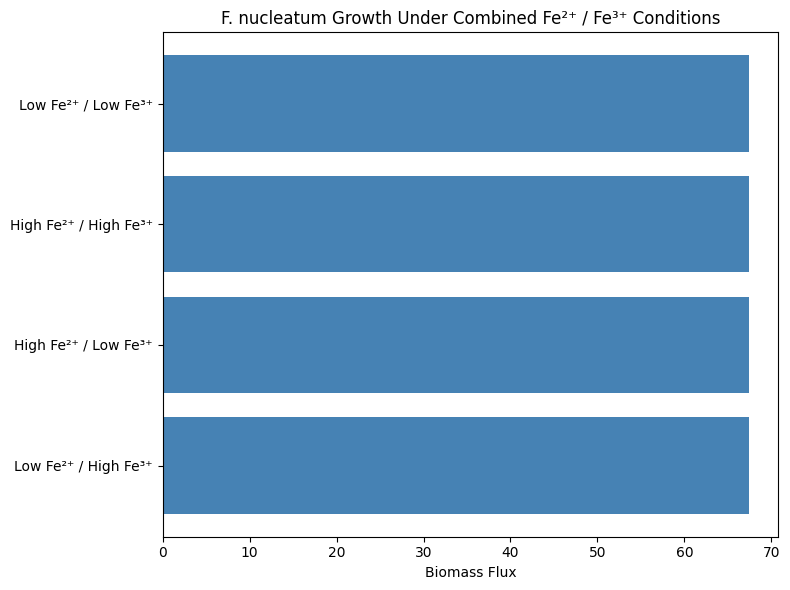

In [ ]:
# ============================================================================
# Run FBA on Iron With limited Reaction and Fail
# ============================================================================
import cobra
import matplotlib.pyplot as plt

# Load the F. nucleatum model
fn_model = cobra.io.read_sbml_model("25586_model.xml")
fn_model.objective = fn_model.reactions.get_by_id("Growth")

# Define combined iron condition scenarios
iron_conditions = [
    ("Low Fe²⁺ / High Fe³⁺",  -0.1, -10.0),
    ("High Fe²⁺ / Low Fe³⁺", -10.0, -0.1),
    ("High Fe²⁺ / High Fe³⁺", -10.0, -10.0),
    ("Low Fe²⁺ / Low Fe³⁺",  -0.1, -0.1),
]

labels = []
fluxes = []

# Run simulations for combined iron conditions
for label, fe2_lb, fe3_lb in iron_conditions:
    temp_model = fn_model.copy()
    
    # Apply bounds
    if "EX_fe2_e" in temp_model.reactions and "EX_fe3_e" in temp_model.reactions:
        temp_model.reactions.get_by_id("EX_fe2_e").lower_bound = fe2_lb
        temp_model.reactions.get_by_id("EX_fe3_e").lower_bound = fe3_lb
        
        # Optimize model
        biomass_flux = temp_model.optimize().objective_value
        labels.append(label)
        fluxes.append(biomass_flux)
    else:
        print("⚠️ Iron exchange reactions not found in model.")
        break

# Plotting
plt.figure(figsize=(8, 6))
plt.barh(labels, fluxes, color='steelblue')
plt.xlabel("Biomass Flux")
plt.title("F. nucleatum Growth Under Combined Fe²⁺ / Fe³⁺ Conditions")
plt.tight_layout()
plt.show()


Adding exchange reaction EX_13ppd_e with default bounds for boundary metabolite: 13ppd_e.
Adding exchange reaction EX_15dap_e with default bounds for boundary metabolite: 15dap_e.
Adding exchange reaction EX_2ameph_e with default bounds for boundary metabolite: 2ameph_e.
Adding exchange reaction EX_2hxmp_e with default bounds for boundary metabolite: 2hxmp_e.
Adding exchange reaction EX_2m35mdntha_e with default bounds for boundary metabolite: 2m35mdntha_e.
Adding exchange reaction EX_2obut_e with default bounds for boundary metabolite: 2obut_e.
Adding exchange reaction EX_2pglyc_e with default bounds for boundary metabolite: 2pglyc_e.
Adding exchange reaction EX_35dnta_e with default bounds for boundary metabolite: 35dnta_e.
Adding exchange reaction EX_3mb_e with default bounds for boundary metabolite: 3mb_e.
Adding exchange reaction EX_4hba_e with default bounds for boundary metabolite: 4hba_e.
Adding exchange reaction EX_4hbald_e with default bounds for boundary metabolite: 4hbald_e

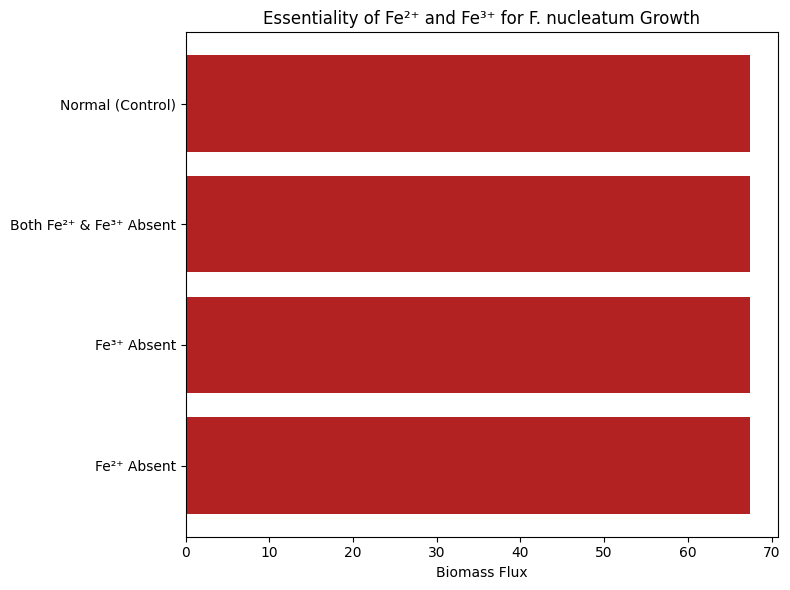

In [43]:
import cobra
import matplotlib.pyplot as plt

# Load the model
fn_model = cobra.io.read_sbml_model("25586_model.xml")
fn_model.objective = fn_model.reactions.get_by_id("Growth")

# Define iron essentiality tests
essentiality_tests = [
    ("Fe²⁺ Absent", 0.0, -10.0),
    ("Fe³⁺ Absent", -10.0, 0.0),
    ("Both Fe²⁺ & Fe³⁺ Absent", 0.0, 0.0),
    ("Normal (Control)", -10.0, -10.0),  # baseline
]

labels = []
fluxes = []

for label, fe2_lb, fe3_lb in essentiality_tests:
    temp_model = fn_model.copy()
    
    try:
        rxn_fe2 = temp_model.reactions.get_by_id("EX_fe2_e")
        rxn_fe3 = temp_model.reactions.get_by_id("EX_fe3_e")
        
        rxn_fe2.lower_bound = fe2_lb
        rxn_fe2.upper_bound = 0.0 if fe2_lb == 0.0 else 1000
        
        rxn_fe3.lower_bound = fe3_lb
        rxn_fe3.upper_bound = 0.0 if fe3_lb == 0.0 else 1000
        
        biomass_flux = temp_model.optimize().objective_value
        labels.append(label)
        fluxes.append(biomass_flux)
    except KeyError:
        print("One or both iron exchange reactions not found in the model.")

# Plot
plt.figure(figsize=(8, 6))
plt.barh(labels, fluxes, color='firebrick')
plt.xlabel("Biomass Flux")
plt.title("Essentiality of Fe²⁺ and Fe³⁺ for F. nucleatum Growth")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# Run FBA Realize iron limitation, scan the model to get all iron related function, rerun analysis
# ============================================================================
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


# Load the metabolic model
model_path = '25586_model.xml'


try:
    model = cobra.io.read_sbml_model(model_path)
    print(f"✓ Model loaded successfully!")
    print(f"  - Reactions: {len(model.reactions)}")
    print(f"  - Metabolites: {len(model.metabolites)}")
    print(f"  - Genes: {len(model.genes)}")
    print(f"  - Objective: {model.objective}")
    
    # Get baseline growth rate
    solution = model.optimize()
    baseline_growth = solution.objective_value
    print(f"  - Baseline growth rate: {baseline_growth:.6f} mmol/gDW/hr")
    
except Exception as e:
    print(f"Error loading model: {e}")

Adding exchange reaction EX_13ppd_e with default bounds for boundary metabolite: 13ppd_e.
Adding exchange reaction EX_15dap_e with default bounds for boundary metabolite: 15dap_e.
Adding exchange reaction EX_2ameph_e with default bounds for boundary metabolite: 2ameph_e.
Adding exchange reaction EX_2hxmp_e with default bounds for boundary metabolite: 2hxmp_e.
Adding exchange reaction EX_2m35mdntha_e with default bounds for boundary metabolite: 2m35mdntha_e.
Adding exchange reaction EX_2obut_e with default bounds for boundary metabolite: 2obut_e.
Adding exchange reaction EX_2pglyc_e with default bounds for boundary metabolite: 2pglyc_e.
Adding exchange reaction EX_35dnta_e with default bounds for boundary metabolite: 35dnta_e.
Adding exchange reaction EX_3mb_e with default bounds for boundary metabolite: 3mb_e.
Adding exchange reaction EX_4hba_e with default bounds for boundary metabolite: 4hba_e.
Adding exchange reaction EX_4hbald_e with default bounds for boundary metabolite: 4hbald_e

Loading F. nucleatum ATCC 25586 metabolic model...


Adding exchange reaction EX_g3pc_e with default bounds for boundary metabolite: g3pc_e.
Adding exchange reaction EX_g3pi_e with default bounds for boundary metabolite: g3pi_e.
Adding exchange reaction EX_g3ps_e with default bounds for boundary metabolite: g3ps_e.
Adding exchange reaction EX_gal_bD_e with default bounds for boundary metabolite: gal_bD_e.
Adding exchange reaction EX_gal_e with default bounds for boundary metabolite: gal_e.
Adding exchange reaction EX_galt_e with default bounds for boundary metabolite: galt_e.
Adding exchange reaction EX_galur_e with default bounds for boundary metabolite: galur_e.
Adding exchange reaction EX_gam_e with default bounds for boundary metabolite: gam_e.
Adding exchange reaction EX_gcald_e with default bounds for boundary metabolite: gcald_e.
Adding exchange reaction EX_glc__D_e with default bounds for boundary metabolite: glc__D_e.
Adding exchange reaction EX_glcn__D_e with default bounds for boundary metabolite: glcn__D_e.
Adding exchange re

✓ Model loaded successfully!
  - Reactions: 1914
  - Metabolites: 1339
  - Genes: 582
  - Objective: Maximize
1.0*Growth - 1.0*Growth_reverse_699ae
  - Baseline growth rate: 67.416545 mmol/gDW/hr


In [49]:
# Comprehensive iron component identification
print("=== IRON COMPONENT ANALYSIS ===")

# 1. Identify iron-related metabolites
iron_keywords = ['fe', 'iron', 'heme', 'hem_', 'ferr', 'siro', 'cytochrome', 'cyt_']
iron_metabolites = []

for met in model.metabolites:
    met_id_lower = met.id.lower()
    met_name_lower = met.name.lower() if met.name else ""
    
    if any(keyword in met_id_lower or keyword in met_name_lower for keyword in iron_keywords):
        iron_metabolites.append(met)

print(f"Found {len(iron_metabolites)} iron-related metabolites:")
iron_met_data = []
for met in iron_metabolites:
    compartment = met.compartment if hasattr(met, 'compartment') else 'unknown'
    iron_met_data.append({
        'id': met.id,
        'name': met.name,
        'compartment': compartment,
        'formula': met.formula if hasattr(met, 'formula') else 'N/A'
    })
    print(f"  {met.id}: {met.name} ({compartment})")

# Convert to DataFrame for easier analysis
iron_met_df = pd.DataFrame(iron_met_data)
print(f"\nIron metabolites by compartment:")
print(iron_met_df['compartment'].value_counts())

=== IRON COMPONENT ANALYSIS ===
Found 40 iron-related metabolites:
  dcyt_c: Deoxycytidine (C_c)
  dscl_c: Dihydrosirohydrochlorin (C_c)
  fcmcbtt_c: Iron(III) chelated carboxymycobactin T (R=8 carbon, final carbon is carboxyl group) (C_c)
  fdxo_2_2_c: Oxidized ferredoxin (C_c)
  fdxrd_c: Reduced ferredoxin (C_c)
  fe2_c: Fe2+ mitochondria (C_c)
  fe2_e: Fe2+ mitochondria (C_e)
  fe2_p: Fe2+ mitochondria (C_p)
  fe3_c: Iron (Fe3+) (C_c)
  fe3_e: Iron (Fe3+) (C_e)
  fe3_p: Iron (Fe3+) (C_p)
  fe3dcit_e: Fe(III)dicitrate (C_e)
  fe3dcit_p: Fe(III)dicitrate (C_p)
  fe3dhbzs3_c: 2-3-dihydroxybenzoylserine trimer-Fe-III (C_c)
  fe3dhbzs3_e: 2-3-dihydroxybenzoylserine trimer-Fe-III (C_e)
  fe3dhbzs3_p: 2-3-dihydroxybenzoylserine trimer-Fe-III (C_p)
  fe3pyovd_kt_e: Ferrypyoverdine  P putida KT2440 specific (C_e)
  fe3pyovd_kt_p: Ferrypyoverdine  P putida KT2440 specific (C_p)
  feenter_c: Fe-enterobactin (C_c)
  feenter_e: Fe-enterobactin (C_e)
  feenter_p: Fe-enterobactin (C_p)
  istfrnA_e

In [51]:
# Load the GenBank file to properly map genes to transport systems
from Bio import SeqIO
import re

genbank_file = '25586_NCBI.gb'

# Parse the genome
record = SeqIO.read(genbank_file, "genbank")
print(f"Loaded genome: {record.description}")
print(f"Length: {len(record.seq):,} bp")

# Now I need to systematically identify iron transport genes by looking at the actual metabolic reactions
# Active transport systems from the metabolic model:
active_transport_systems = {
    'FE2t': {'flux': 0.4527021023310352, 'type': 'Fe2+', 'description': 'Ferrous iron transport'},
    'FE3t': {'flux': 0.526388386448358, 'type': 'Fe3+', 'description': 'Ferric iron transport'},
    'FE3PYOVDL2': {'flux': -0.526388386448358, 'type': 'Fe3+', 'description': 'Fe3+ pyoverdine transport'}
}

print("\n=== ACTIVE IRON TRANSPORT SYSTEMS FROM METABOLIC MODEL ===")
for rxn_id, info in active_transport_systems.items():
    print(f"{rxn_id}: {info['description']} (flux: {info['flux']:.4f})")

# Now I need to find genes that could correspond to these transport systems
# Search for iron transport genes more comprehensively
iron_transport_genes = []

# Keywords for Fe2+ transporters
fe2_keywords = [
    'ferrous', 'fe2', 'fe(ii)', 'feoA', 'feoB', 'feoC', 'iron(ii)', 
    'divalent metal', 'nramp', 'dmt1', 'irt1', 'zip'
]

# Keywords for Fe3+ transporters  
fe3_keywords = [
    'ferric', 'fe3', 'fe(iii)', 'iron(iii)', 'fecA', 'fecB', 'fecC', 'fecD', 'fecE',
    'fhuA', 'fhuB', 'fhuC', 'fhuD', 'fepA', 'fepB', 'fepC', 'fepD', 'fepG',
    'enterobactin', 'siderophore', 'citrate', 'hydroxamate'
]

# Search through all CDS features
for feature in record.features:
    if feature.type == "CDS":
        locus_tag = feature.qualifiers.get('locus_tag', [''])[0]
        product = feature.qualifiers.get('product', [''])[0]
        gene = feature.qualifiers.get('gene', [''])[0]
        
        product_lower = product.lower()
        gene_lower = gene.lower()
        
        # Check for Fe2+ transport
        fe2_match = any(keyword in product_lower or keyword in gene_lower 
                       for keyword in fe2_keywords)
        
        # Check for Fe3+ transport
        fe3_match = any(keyword in product_lower or keyword in gene_lower 
                       for keyword in fe3_keywords)
        
        # Check for general iron transport
        iron_match = any(keyword in product_lower 
                        for keyword in ['iron transport', 'iron uptake', 'iron abc'])
        
        if fe2_match or fe3_match or iron_match:
            transport_type = []
            if fe2_match:
                transport_type.append('Fe2+')
            if fe3_match:
                transport_type.append('Fe3+')
            if iron_match and not (fe2_match or fe3_match):
                transport_type.append('General')
                
            iron_transport_genes.append({
                'locus_tag': locus_tag,
                'gene': gene,
                'product': product,
                'type': '/'.join(transport_type)
            })

print(f"\n=== IRON TRANSPORT GENES IDENTIFIED ===")
print(f"Found {len(iron_transport_genes)} iron transport genes:")
for gene in iron_transport_genes:
    print(f"  {gene['locus_tag']} ({gene['type']}): {gene['product']}")

Loaded genome: Fusobacterium nucleatum subsp. nucleatum ATCC 25586, complete genome
Length: 2,174,500 bp

=== ACTIVE IRON TRANSPORT SYSTEMS FROM METABOLIC MODEL ===
FE2t: Ferrous iron transport (flux: 0.4527)
FE3t: Ferric iron transport (flux: 0.5264)
FE3PYOVDL2: Fe3+ pyoverdine transport (flux: -0.5264)

=== IRON TRANSPORT GENES IDENTIFIED ===
Found 18 iron transport genes:
  FN2045 (Fe3+): Ferric uptake regulation protein
  FN0300 (Fe3+): Iron(III) dicitrate-binding protein
  FN0301 (Fe3+): Iron(III) dicitrate transport system permease protein fecD
  FN0302 (Fe3+): Iron(III) dicitrate transport ATP-binding protein fecE
  FN0305 (Fe3+): Iron(III) dicitrate-binding protein
  FN0306 (Fe3+): Iron(III) dicitrate transport system permease protein fecD
  FN0307 (Fe3+): Iron(III) dicitrate transport ATP-binding protein fecE
  FN0308 (Fe3+): Iron(III)-binding protein
  FN0309 (Fe3+): Iron(III)-transport system permease protein sfuB
  FN0310 (Fe3+): Iron(III)-transport ATP-binding protein sfuC

In [53]:
# 2. Identify iron-related reactions
print("\n=== IRON REACTION ANALYSIS ===")

iron_reactions = []
iron_met_ids = [met.id for met in iron_metabolites]

for rxn in model.reactions:
    # Check if any iron metabolites are involved in this reaction
    rxn_metabolites = [met.id for met in rxn.metabolites]
    if any(iron_met in rxn_metabolites for iron_met in iron_met_ids):
        iron_reactions.append(rxn)

print(f"Found {len(iron_reactions)} reactions involving iron metabolites:")

# Categorize reactions by function
reaction_categories = {
    'Transport': [],
    'Exchange': [],
    'Biosynthesis': [],
    'Utilization': [],
    'Other': []
}

for rxn in iron_reactions:
    rxn_id = rxn.id
    rxn_name = rxn.name if rxn.name else "No name"
    
    if rxn_id.startswith('EX_'):
        reaction_categories['Exchange'].append(rxn)
    elif any(keyword in rxn_id.lower() for keyword in ['t', 'abc', 'trans']):
        reaction_categories['Transport'].append(rxn)
    elif any(keyword in rxn_id.lower() for keyword in ['synth', 'fclt', 'hems']):
        reaction_categories['Biosynthesis'].append(rxn)
    elif any(keyword in rxn_id.lower() for keyword in ['utilizl', 'ester', 'oxid', 'red']):
        reaction_categories['Utilization'].append(rxn)
    else:
        reaction_categories['Other'].append(rxn)

print("\nReaction categories:")
for category, reactions in reaction_categories.items():
    print(f"  {category}: {len(reactions)} reactions")
    for rxn in reactions[:5]:  # Show first 5 examples
        print(f"    {rxn.id}: {rxn.name}")
    if len(reactions) > 5:
        print(f"    ... and {len(reactions) - 5} more")


=== IRON REACTION ANALYSIS ===
Found 70 reactions involving iron metabolites:

Reaction categories:
  Transport: 39 reactions
    CMCBTFL: CMCBTFL
    CMCBTFU: CMCBTFU
    DHBSZ3FEabcpp: 23dhbsz3 Fe III transport via ABC system periplasm
    DHBSZ3FEtonex: 23dhbsz3  Fe III import
    ENTERES2: Enterochelin Esterase (Fe containing)
    ... and 34 more
  Exchange: 14 reactions
    EX_fe2_e: EX_fe2_e
    EX_fe3_e: EX_fe3_e
    EX_fe3dcit_e: EX_fe3dcit_e
    EX_fe3dhbzs3_e: EX_fe3dhbzs3_e
    EX_fe3pyovd_kt_e: EX_fe3pyovd_kt_e
    ... and 9 more
  Biosynthesis: 0 reactions
  Utilization: 0 reactions
  Other: 17 reactions
    ADADir: Deoxycytidine kinase
    ALMPC: 
    FE3DHBZS3R: Fe(III)-(2,3-dihydroxybenzoylserine)3 reductase via NADPH
    FE3PYOVDDR2: Ferrypyoverdine  dissociation reduction  Pputida specific
    FE3PYOVDL2: Ferripyoverdine complex formation  P putida KT2440 specific
    ... and 12 more


In [55]:
# 3. Analyze biomass composition for iron requirements
print("\n=== BIOMASS COMPOSITION ANALYSIS ===")

# Find the biomass/growth reaction
biomass_reaction = None
for rxn in model.reactions:
    if 'growth' in rxn.id.lower() or 'biomass' in rxn.id.lower():
        biomass_reaction = rxn
        break

if biomass_reaction:
    print(f"Biomass reaction found: {biomass_reaction.id}")
    print(f"Reaction equation: {biomass_reaction.build_reaction_string()}")
    
    # Find iron-containing metabolites in biomass
    iron_in_biomass = []
    for met, coeff in biomass_reaction.metabolites.items():
        if any(iron_met.id == met.id for iron_met in iron_metabolites):
            iron_in_biomass.append((met, coeff))
            print(f"  Iron metabolite in biomass: {met.id} = {coeff}")
    
    if iron_in_biomass:
        print(f"\n✓ IRON IS REQUIRED IN BIOMASS COMPOSITION!")
        total_iron_requirement = sum(abs(coeff) for met, coeff in iron_in_biomass)
        print(f"Total iron requirement per unit biomass: {total_iron_requirement:.6f}")
    else:
        print("\n⚠ No direct iron metabolites found in biomass composition")
        print("Checking for iron-containing cofactors and prosthetic groups...")
        
        # Check for heme, cytochromes, and other iron-containing compounds
        for met, coeff in biomass_reaction.metabolites.items():
            met_name_lower = met.name.lower() if met.name else ""
            met_id_lower = met.id.lower()
            if any(keyword in met_name_lower or keyword in met_id_lower 
                   for keyword in ['heme', 'cytochrome', 'iron', 'fe']):
                print(f"  Potential iron-containing metabolite: {met.id} ({met.name}) = {coeff}")
else:
    print("⚠ Biomass reaction not found")


=== BIOMASS COMPOSITION ANALYSIS ===
Biomass reaction found: Growth
Reaction equation: 0.000223 10fthf_c + 0.513689 ala__L_c + 0.000223 amet_c + 0.295792 arg__L_c + 0.241055 asn__L_c + 0.241055 asp__L_c + 54.124831 atp_c + 0.005205 ca2_c + 0.005205 cl_c + 0.000576 coa_c + 0.0001 cobalt2_c + 0.133508 ctp_c + 0.000709 cu2_c + 0.09158 cys__L_c + 0.026166 datp_c + 0.027017 dctp_c + 0.027017 dgtp_c + 0.026166 dttp_c + 0.000223 fad_c + 0.006715 fe2_c + 0.007808 fe3_c + 0.26316 gln__L_c + 0.26316 glu__L_c + 0.612638 gly_c + 0.215096 gtp_c + 48.601527 h2o_c + 0.094738 his__L_c + 0.290529 ile__L_c + 0.195193 k_c + 0.450531 leu__L_c + 0.343161 lys__L_c + 0.153686 met__L_c + 0.008675 mg2_c + 0.000223 mlthf_c + 0.000691 mn2_c + 0.0001 mql8_c + 0.001831 nad_c + 0.000447 nadp_c + 0.185265 phe__L_c + 0.221055 pro__L_c + 0.000223 pydx5p_c + 0.000223 ribflv_c + 0.215792 ser__L_c + 0.004338 so4_c + 0.000223 thf_c + 0.000223 thmpp_c + 0.253687 thr__L_c + 0.056843 trp__L_c + 0.137896 tyr__L_c + 0.1 uaagm

In [57]:
# 4. Perform FBA under different iron availability conditions
print("\n=== FLUX BALANCE ANALYSIS UNDER IRON CONDITIONS ===")

# Identify iron exchange reactions
iron_exchange_reactions = [rxn for rxn in model.reactions if rxn.id.startswith('EX_') and 
                          any(iron_met.id in [met.id for met in rxn.metabolites] 
                              for iron_met in iron_metabolites)]

print(f"Found {len(iron_exchange_reactions)} iron exchange reactions:")
for rxn in iron_exchange_reactions:
    print(f"  {rxn.id}: {rxn.name} | Bounds: {rxn.bounds}")

# Save original bounds
original_bounds = {}
for rxn in iron_exchange_reactions:
    original_bounds[rxn.id] = rxn.bounds

# Test different iron conditions
iron_conditions = {
    'Rich_Iron': 'Unlimited iron availability',
    'Limited_Iron': 'Limited iron uptake (-1.0 to 0)',
    'Low_Iron': 'Very low iron uptake (-0.1 to 0)', 
    'No_Iron': 'No iron uptake (0 to 0)'
}

fba_results = {}

for condition, description in iron_conditions.items():
    print(f"\n--- Testing {condition}: {description} ---")
    
    # Set iron constraints based on condition
    if condition == 'Rich_Iron':
        # Keep original bounds (usually unlimited)
        for rxn in iron_exchange_reactions:
            rxn.bounds = original_bounds[rxn.id]
    elif condition == 'Limited_Iron':
        for rxn in iron_exchange_reactions:
            rxn.bounds = (-1.0, 0)  # Limited uptake
    elif condition == 'Low_Iron':
        for rxn in iron_exchange_reactions:
            rxn.bounds = (-0.1, 0)  # Very low uptake
    elif condition == 'No_Iron':
        for rxn in iron_exchange_reactions:
            rxn.bounds = (0, 0)  # No uptake allowed
    
    # Perform FBA
    try:
        solution = model.optimize()
        if solution.status == 'optimal':
            growth_rate = solution.objective_value
            print(f"  Growth rate: {growth_rate:.6f} h⁻¹")
            
            # Get iron exchange fluxes
            iron_fluxes = {}
            for rxn in iron_exchange_reactions:
                flux = solution.fluxes[rxn.id]
                iron_fluxes[rxn.id] = flux
                if abs(flux) > 1e-6:  # Only show non-zero fluxes
                    print(f"    {rxn.id}: {flux:.6f}")
            
            fba_results[condition] = {
                'growth_rate': growth_rate,
                'status': solution.status,
                'iron_fluxes': iron_fluxes
            }
        else:
            print(f"  ⚠ Solution status: {solution.status}")
            fba_results[condition] = {
                'growth_rate': 0,
                'status': solution.status,
                'iron_fluxes': {}
            }
    except Exception as e:
        print(f"  ✗ Error: {e}")
        fba_results[condition] = {
            'growth_rate': 0,
            'status': 'error',
            'iron_fluxes': {}
        }

# Restore original bounds
for rxn in iron_exchange_reactions:
    rxn.bounds = original_bounds[rxn.id]

print(f"\n=== FBA RESULTS SUMMARY ===")
for condition, results in fba_results.items():
    print(f"{condition}: {results['growth_rate']:.6f} h⁻¹ ({results['status']})")


=== FLUX BALANCE ANALYSIS UNDER IRON CONDITIONS ===
Found 14 iron exchange reactions:
  EX_fe2_e: EX_fe2_e | Bounds: (-1000.0, 1000.0)
  EX_fe3_e: EX_fe3_e | Bounds: (-1000.0, 1000.0)
  EX_fe3dcit_e: EX_fe3dcit_e | Bounds: (-1000.0, 1000.0)
  EX_fe3dhbzs3_e: EX_fe3dhbzs3_e | Bounds: (-1000.0, 1000.0)
  EX_fe3pyovd_kt_e: EX_fe3pyovd_kt_e | Bounds: (-1000.0, 1000.0)
  EX_feenter_e: EX_feenter_e | Bounds: (-1000.0, 1000.0)
  EX_istfrnA_e: EX_istfrnA_e | Bounds: (-1000.0, 1000.0)
  EX_istfrnB_e: EX_istfrnB_e | Bounds: (-1000.0, 1000.0)
  EX_pheme_e: EX_pheme_e | Bounds: (-1000.0, 1000.0)
  EX_salchs2fe_e: EX_salchs2fe_e | Bounds: (-1000.0, 1000.0)
  EX_salchs4fe_e: EX_salchs4fe_e | Bounds: (-1000.0, 1000.0)
  EX_sheme_e: EX_sheme_e | Bounds: (-1000.0, 1000.0)
  EX_stfrnA_e: EX_stfrnA_e | Bounds: (-1000.0, 1000.0)
  EX_stfrnB_e: EX_stfrnB_e | Bounds: (-1000.0, 1000.0)

--- Testing Rich_Iron: Unlimited iron availability ---
  Growth rate: 67.416545 h⁻¹
    EX_fe2_e: -0.452702
    EX_fe3_e: 

In [59]:
# 5. Analyze iron flux distributions and dependencies
print("\n=== IRON FLUX DISTRIBUTION ANALYSIS ===")

# Re-run the Rich Iron condition to get detailed flux analysis
model.optimize()
solution = model.optimize()

# Analyze all iron-related reaction fluxes
iron_reaction_fluxes = []
for rxn in iron_reactions:
    flux = solution.fluxes[rxn.id]
    if abs(flux) > 1e-6:  # Only include active reactions
        iron_reaction_fluxes.append({
            'reaction_id': rxn.id,
            'reaction_name': rxn.name,
            'flux': flux,
            'category': 'Exchange' if rxn.id.startswith('EX_') else 
                       'Transport' if any(keyword in rxn.id.lower() for keyword in ['t', 'abc', 'trans']) else
                       'Other'
        })

iron_flux_df = pd.DataFrame(iron_reaction_fluxes)
print(f"Found {len(iron_flux_df)} active iron-related reactions:")
print(iron_flux_df.sort_values('flux', key=abs, ascending=False).to_string())

# Calculate iron utilization efficiency
if len(iron_flux_df) > 0:
    total_iron_uptake = abs(iron_flux_df[iron_flux_df['flux'] < 0]['flux'].sum())
    growth_rate = solution.objective_value
    iron_efficiency = growth_rate / total_iron_uptake if total_iron_uptake > 0 else 0
    print(f"\nIron utilization efficiency: {iron_efficiency:.3f} h⁻¹ per unit iron uptake")

# Identify essential iron pathways
print(f"\n=== ESSENTIAL IRON PATHWAYS ===")
essential_pathways = {
    'Iron uptake': [rxn for rxn in iron_reactions if rxn.id.startswith('EX_')],
    'Iron transport': [rxn for rxn in iron_reactions if any(keyword in rxn.id.lower() 
                                                          for keyword in ['t', 'abc', 'pp'])],
    'Heme metabolism': [rxn for rxn in iron_reactions if 'heme' in rxn.id.lower() or 'hem' in rxn.id.lower()],
    'Iron-sulfur clusters': [rxn for rxn in iron_reactions if any(keyword in rxn.id.lower() 
                                                                for keyword in ['fdx', 'fe2s2', 'fe4s4'])],
    'Siderophore systems': [rxn for rxn in iron_reactions if any(keyword in rxn.id.lower() 
                                                               for keyword in ['enter', 'salch', 'dhbz'])]
}

for pathway, reactions in essential_pathways.items():
    active_reactions = [rxn for rxn in reactions if abs(solution.fluxes[rxn.id]) > 1e-6]
    print(f"\n{pathway}: {len(active_reactions)}/{len(reactions)} reactions active")
    for rxn in active_reactions[:3]:  # Show top 3
        flux = solution.fluxes[rxn.id]
        print(f"  {rxn.id}: {flux:.6f}")


=== IRON FLUX DISTRIBUTION ANALYSIS ===
Found 11 active iron-related reactions:
         reaction_id                                                reaction_name        flux   category
8            POR_syn                           Pyruvate-ferredoxin oxidoreductase  848.561939      Other
6               FNOR                                 Ferredoxin---NADP+ reductase  811.455873      Other
7          MECDPDH4E                                                                74.212133      Other
10            Growth                                             Biomass reaction   67.416545  Transport
0   EX_fe3pyovd_kt_e                                             EX_fe3pyovd_kt_e   -0.526388   Exchange
4         FE3PYOVDL2  Ferripyoverdine complex formation  P putida KT2440 specific   -0.526388      Other
5               FE3t                          Ferric iron uptake, plasma membrane    0.526388  Transport
2        EX_stfrnA_e                                                  EX_stfrnA

=== CREATING COMPREHENSIVE VISUALIZATIONS ===


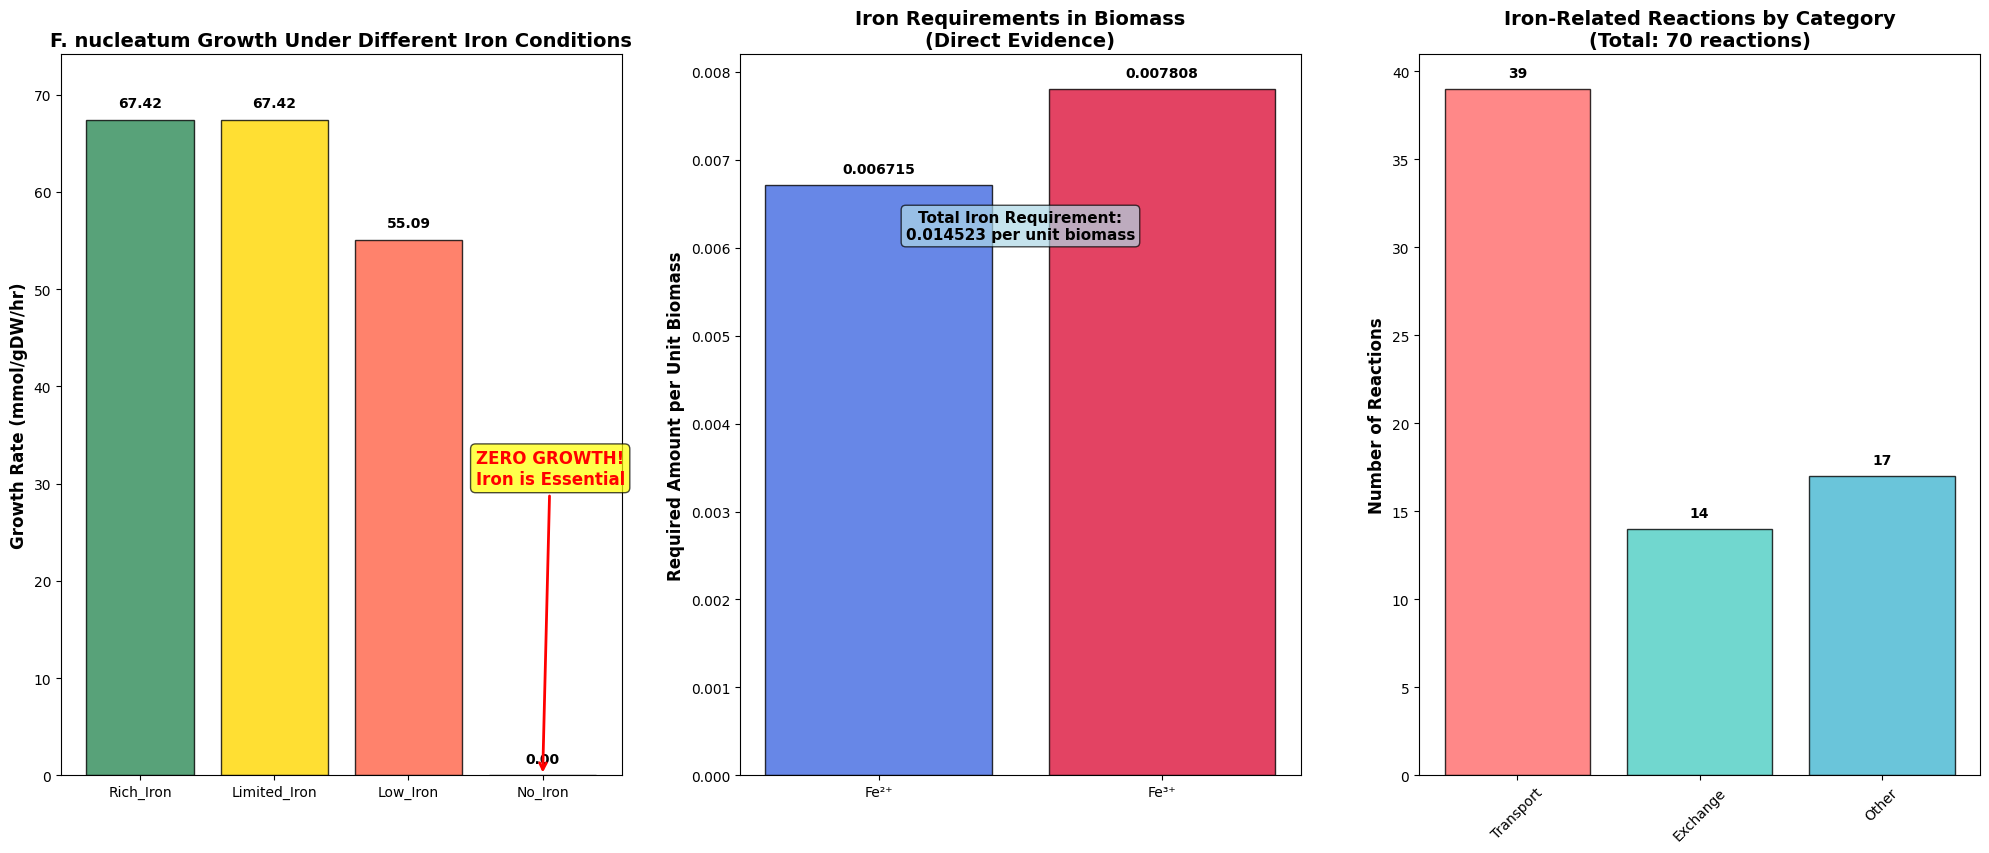

Comprehensive analysis figure saved to: iron_essentiality_comprehensive_analysis.png


In [65]:
# 6. Create comprehensive visualizations
print("=== CREATING COMPREHENSIVE VISUALIZATIONS ===")

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Growth Rate under Different Iron Conditions
ax1 = plt.subplot(2, 3, 1)
conditions = list(fba_results.keys())
growth_rates = [fba_results[cond]['growth_rate'] for cond in conditions]
colors = ['#2E8B57', '#FFD700', '#FF6347', '#8B0000']

bars = ax1.bar(conditions, growth_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_ylabel('Growth Rate (mmol/gDW/hr)', fontsize=12, fontweight='bold')
ax1.set_title('F. nucleatum Growth Under Different Iron Conditions', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(growth_rates) * 1.1)

# Add value labels on bars
for bar, rate in zip(bars, growth_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{rate:.2f}', ha='center', va='bottom', fontweight='bold')

# Add annotation for zero growth
ax1.annotate('ZERO GROWTH!\nIron is Essential', 
             xy=(3, 0), xytext=(2.5, 30),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# 3. Iron in Biomass Composition
ax3 = plt.subplot(2, 3, 2)
iron_types = ['Fe²⁺', 'Fe³⁺']
iron_amounts = [0.006715, 0.007808]
colors_iron = ['#4169E1', '#DC143C']

bars_biomass = ax3.bar(iron_types, iron_amounts, color=colors_iron, alpha=0.8, 
                       edgecolor='black', linewidth=1)
ax3.set_ylabel('Required Amount per Unit Biomass', fontsize=12, fontweight='bold')
ax3.set_title('Iron Requirements in Biomass\n(Direct Evidence)', fontsize=14, fontweight='bold')

for bar, amount in zip(bars_biomass, iron_amounts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{amount:.6f}', ha='center', va='bottom', fontweight='bold')

# Add total iron requirement annotation
total_iron = sum(iron_amounts)
ax3.text(0.5, max(iron_amounts) * 0.8, 
         f'Total Iron Requirement:\n{total_iron:.6f} per unit biomass',
         ha='center', va='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# 4. Iron Reaction Categories
ax4 = plt.subplot(2, 3, 3)
category_counts = {cat: len(reactions) for cat, reactions in reaction_categories.items() if len(reactions) > 0}
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars_cat = ax4.bar(category_counts.keys(), category_counts.values(), 
                   color=colors_cat[:len(category_counts)], alpha=0.8,
                   edgecolor='black', linewidth=1)
ax4.set_ylabel('Number of Reactions', fontsize=12, fontweight='bold')
ax4.set_title('Iron-Related Reactions by Category\n(Total: 70 reactions)', 
              fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

for bar, count in zip(bars_cat, category_counts.values()):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{count}', ha='center', va='bottom', fontweight='bold')


plt.tight_layout()

# Save the figure
output_path = 'iron_essentiality_comprehensive_analysis.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Comprehensive analysis figure saved to: {output_path}")

Creating detailed iron flux analysis...


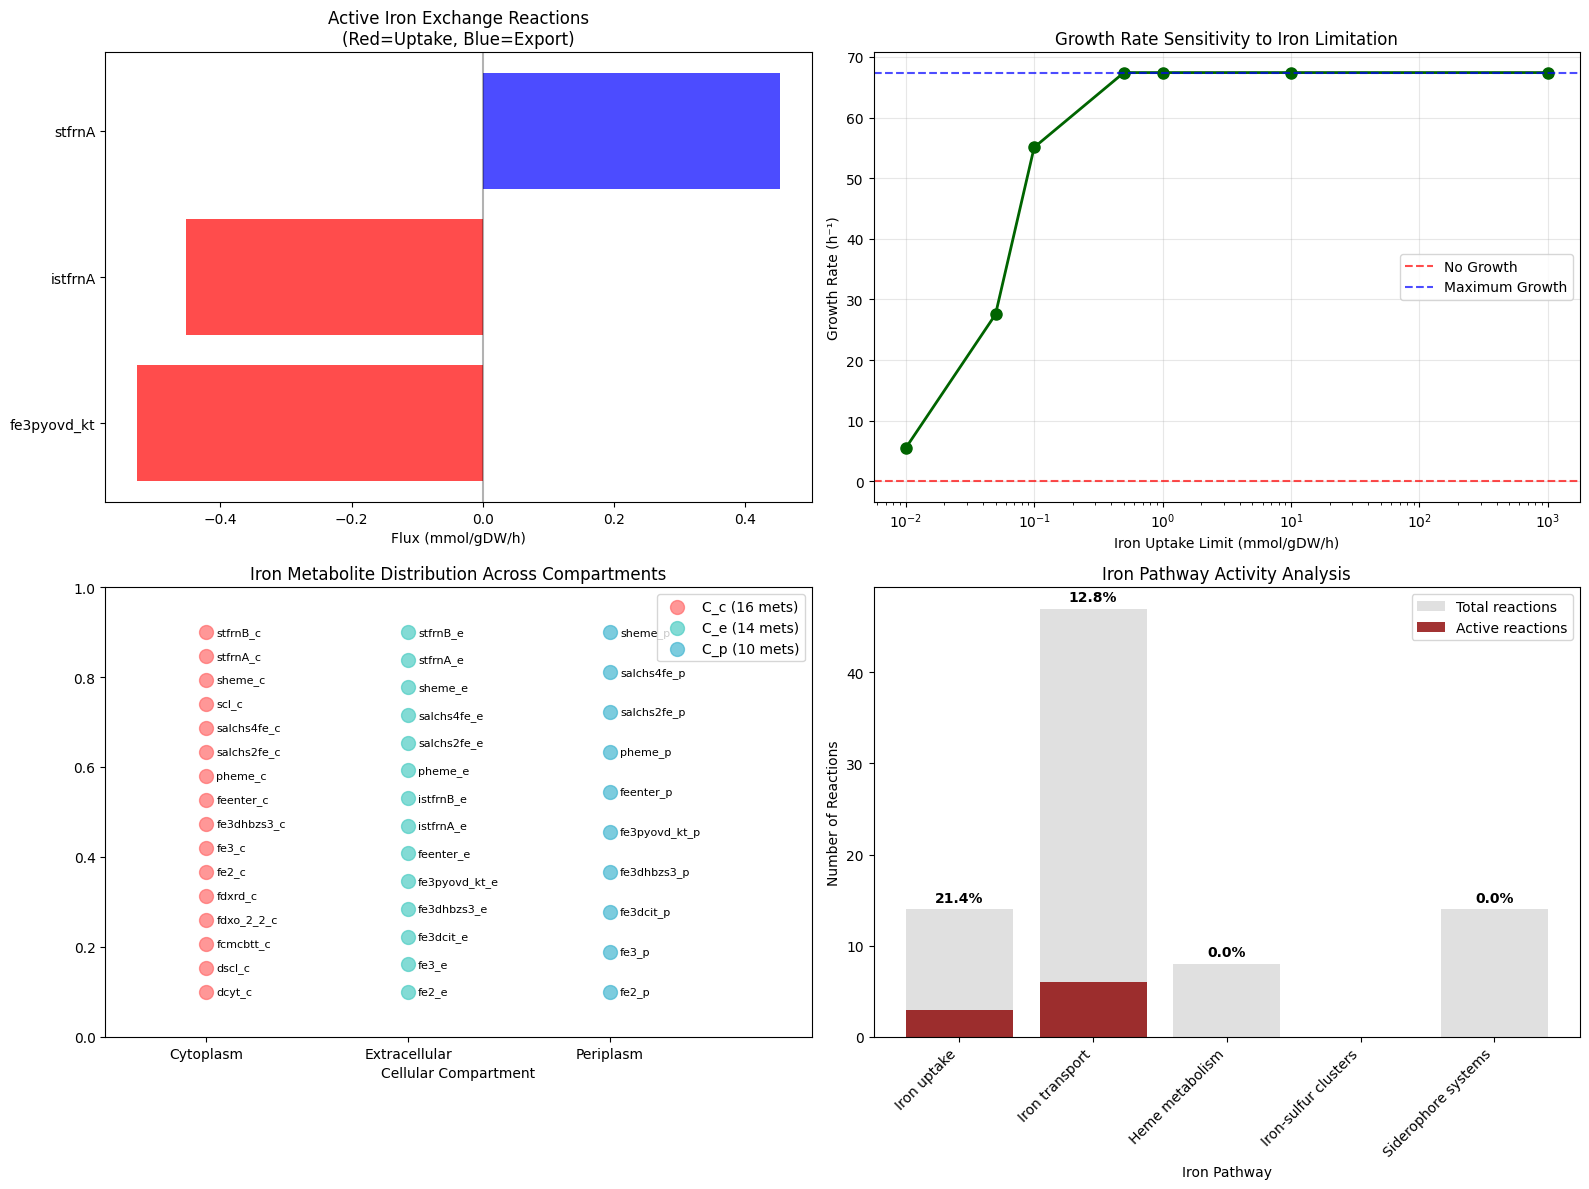

In [67]:
# Create additional detailed flux analysis visualization
print("Creating detailed iron flux analysis...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Iron Exchange Reactions Activity
iron_exchange_data = []
for rxn in iron_exchange_reactions:
    flux = solution.fluxes[rxn.id]
    if abs(flux) > 1e-6:
        iron_exchange_data.append({
            'reaction': rxn.id.replace('EX_', '').replace('_e', ''),
            'flux': flux,
            'direction': 'Uptake' if flux < 0 else 'Export'
        })

if iron_exchange_data:
    df_exchange = pd.DataFrame(iron_exchange_data)
    
    # Separate uptake and export
    uptake_data = df_exchange[df_exchange['direction'] == 'Uptake']
    export_data = df_exchange[df_exchange['direction'] == 'Export']
    
    y_pos = np.arange(len(df_exchange))
    colors = ['red' if flux < 0 else 'blue' for flux in df_exchange['flux']]
    
    bars = ax1.barh(y_pos, df_exchange['flux'], color=colors, alpha=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(df_exchange['reaction'])
    ax1.set_xlabel('Flux (mmol/gDW/h)')
    ax1.set_title('Active Iron Exchange Reactions\n(Red=Uptake, Blue=Export)')
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 2. Growth Rate Sensitivity to Iron Limitation
iron_limits = [1000, 10, 1, 0.5, 0.1, 0.05, 0.01, 0]
sensitivity_results = []

for limit in iron_limits:
    # Set iron exchange bounds
    for rxn in iron_exchange_reactions:
        if limit > 0:
            rxn.bounds = (-limit, 0)
        else:
            rxn.bounds = (0, 0)
    
    try:
        sol = model.optimize()
        growth = sol.objective_value if sol.status == 'optimal' else 0
        sensitivity_results.append(growth)
    except:
        sensitivity_results.append(0)

# Restore original bounds
for rxn in iron_exchange_reactions:
    rxn.bounds = original_bounds[rxn.id]

ax2.plot(iron_limits[:-1], sensitivity_results[:-1], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='No Growth')
ax2.axhline(y=67.416545, color='blue', linestyle='--', alpha=0.7, label='Maximum Growth')
ax2.set_xlabel('Iron Uptake Limit (mmol/gDW/h)')
ax2.set_ylabel('Growth Rate (h⁻¹)')
ax2.set_title('Growth Rate Sensitivity to Iron Limitation')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Iron Metabolite Network
# Create a network-style visualization of iron metabolites
compartments = iron_met_df['compartment'].unique()
comp_colors = {'C_c': '#FF6B6B', 'C_e': '#4ECDC4', 'C_p': '#45B7D1'}

for i, comp in enumerate(compartments):
    comp_mets = iron_met_df[iron_met_df['compartment'] == comp]
    y_positions = np.linspace(0.1, 0.9, len(comp_mets))
    x_position = i * 0.4 + 0.1
    
    for j, (_, met) in enumerate(comp_mets.iterrows()):
        ax3.scatter(x_position, y_positions[j], s=100, 
                   color=comp_colors.get(comp, 'gray'), alpha=0.7)
        ax3.text(x_position + 0.02, y_positions[j], met['id'], 
                fontsize=8, va='center')

ax3.set_xlim(-0.1, 1.3)
ax3.set_ylim(0, 1)
ax3.set_xlabel('Cellular Compartment')
ax3.set_title('Iron Metabolite Distribution Across Compartments')
ax3.set_xticks([0.1, 0.5, 0.9])
ax3.set_xticklabels(['Cytoplasm', 'Extracellular', 'Periplasm'])

# Add compartment legend
for comp, color in comp_colors.items():
    ax3.scatter([], [], color=color, s=100, alpha=0.7, 
               label=f'{comp} ({len(iron_met_df[iron_met_df["compartment"]==comp])} mets)')
ax3.legend(loc='upper right')

# 4. Essential vs Non-essential Iron Pathways
pathway_activity = {}
for pathway, reactions in essential_pathways.items():
    active_count = sum(1 for rxn in reactions if abs(solution.fluxes[rxn.id]) > 1e-6)
    total_count = len(reactions)
    activity_ratio = active_count / total_count if total_count > 0 else 0
    pathway_activity[pathway] = {
        'active': active_count,
        'total': total_count,
        'ratio': activity_ratio
    }

pathways = list(pathway_activity.keys())
active_counts = [pathway_activity[p]['active'] for p in pathways]
total_counts = [pathway_activity[p]['total'] for p in pathways]

x_pos = np.arange(len(pathways))
ax4.bar(x_pos, total_counts, color='lightgray', alpha=0.7, label='Total reactions')
ax4.bar(x_pos, active_counts, color='darkred', alpha=0.8, label='Active reactions')

ax4.set_xlabel('Iron Pathway')
ax4.set_ylabel('Number of Reactions')
ax4.set_title('Iron Pathway Activity Analysis')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(pathways, rotation=45, ha='right')
ax4.legend()

# Add activity percentages
for i, (active, total) in enumerate(zip(active_counts, total_counts)):
    if total > 0:
        percentage = (active / total) * 100
        ax4.text(i, total + 0.5, f'{percentage:.1f}%', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# Save the detailed flux analysis
plt.savefig('iron_flux_detailed_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ============================================================================
# Essential gene and iron homeostasis analysis
# retrieval of the predicted essential gene set for F. nucleatum ATCC 25586 from the NetGenes database
# It is a CVS, from citation in the paper, you can directly download it
#cross-referencing of STRING-DB gene identifiers against the NCBI GenBank annotation (AE009951.2) 
#using BioPython SeqIO to resolve entries lacking functional annotation in the NetGenes output
#Since it is CVS with all label such as FN### list, it match my Supplementary_Table_S1 name, so easy to do search.
#keyword-based classification of iron homeostasis-related essential genes using the terms: 
#iron, heme, hmu, ferritin, ferro, fbp, tonB, exbB, exbD, feo, hemin, fhuA, abc transporter, hemolysin, shlB, tlyA; 
# identification of 20 essential genes with predicted roles in iron homeostasis and transport, 
# including  FbpC (FN0376) and multiple TonB-dependent receptor components;
# ============================================================================

#uses direct gene name matching

import pandas as pd

# Load NetGenes (essential gene) CSV
netgenes = pd.read_excel('Fusobacterium nucleatum ATCC25586.xlsx')

# List of iron acquisition genes from your annotation/work 
iron_genes = [
    'fbpC', 'tonB', 'hmuT', 'hmuU', 'hmuV', 'exbB', 'exbD', 'ABC transporters','fhuA', 'feoB', 'hemolysin', 
    'shlB3', 'shlB2', 'shlB1', 'tlyA', 'Fn1792', 'Fap2', 'FadA', 'RadD', 'FomA', 'lysozyme'
]

# Lowercase for robust comparison
netgenes['Preferred Gene Name Lower'] = netgenes['Preferred Gene Name'].astype(str).str.lower()
iron_genes_lower = [gene.lower() for gene in iron_genes]

# Filter for essential iron acquisition genes
mapped = netgenes[netgenes['Preferred Gene Name Lower'].isin(iron_genes_lower)]

print("Essential genes in iron acquisition pathway:")
print(mapped[['Preferred Gene Name', 'Annotation', 'Confidence Score']])

# Optionally save to a file
mapped.to_excel('essential_iron_genes.xlsx', index=False)




In [ ]:
#uses BioPython GenBank cross-referencing with keyword matching.
import pandas as pd
from collections import defaultdict
from Bio import SeqIO

# -----------------------------
# SETTINGS (file paths/names)
# -----------------------------
xls_file = 'Fusobacterium nucleatum ATCC25586.xlsx'
gb_file = '25586_NCBI.gb'

# -----------------------------
# Load Excel file
# -----------------------------
df = pd.read_excel(xls_file)

# -----------------------------
# Parse GenBank and map locus_tag to list of products
# -----------------------------
locus2products = defaultdict(list)

for record in SeqIO.parse(gb_file, 'genbank'):
    for feature in record.features:
        if feature.type in ('gene', 'CDS'):
            locus_tag = feature.qualifiers.get('locus_tag', [''])[0]
            product = feature.qualifiers.get('product', [''])[0]
            if locus_tag and product:  # Both present
                locus2products[locus_tag].append(product)

# -----------------------------
# Iron gene keywords (edit as needed)
# -----------------------------
iron_terms = [
    'iron', 'hemolysin', 'heme', 'hmu', 'ferritin', 'ferro', 'fbp', 'tonB', 'exbB', 'exbD', 'feo', 'hemin',
    'fhuA', 'shlB3', 'shlB2', 'shlB1', 'tlyA', 'fn1792', 'fap2', 'fada', 'radd', 'foma', 'lysozyme', 'abc transporter'
]

def is_iron_gene(product_str):
    """Returns True if any iron keyword is in product string (case-insensitive)."""
    return any(term in product_str.lower() for term in iron_terms)

# -----------------------------
# Update annotations and detect iron genes
# -----------------------------
new_annotations = []
is_iron_flags = []

for idx, row in df.iterrows():
    anno = row['Annotation']
    string_db_id = row['STRING-DB ID']
    locus_tag = string_db_id.split('.')[-1]
    products_list = locus2products.get(locus_tag, [])
    products_joined = "; ".join(products_list) if products_list else ""
    # Use products from GenBank if missing annotation, else keep original
    if anno.strip() == 'annotation not available' and products_joined:
        use_anno = products_joined
    else:
        use_anno = anno
    # Mark as iron-related if any product or annotation matches
    is_iron = is_iron_gene(use_anno)
    new_annotations.append(use_anno)
    is_iron_flags.append(is_iron)

df['New Annotation'] = new_annotations
df['Is Iron-related'] = is_iron_flags

# Filter for iron-related genes
df_iron_genes = df[df['Is Iron-related']]

# Save output and print result
df_iron_genes.to_excel('essential_iron_genes_with_products.xlsx', index=False)
print(df_iron_genes[['STRING-DB ID', 'Preferred Gene Name', 'New Annotation', 'Confidence Score']])